# Detecção de Emoções via Ensemble Fuzzy
## Uma abordagem focada em interpretabilidade

**Contexto de aplicação:** um consultor monitora mensagens de pacientes. O sistema não precisa
apenas acertar — precisa **explicar** por que sinalizou uma emoção, com regras auditáveis e
graus de pertinência legíveis por um humano.

In [3]:
import warnings
warnings.filterwarnings("ignore")

import re
import json
import time
import math
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Optimizer

from transformers import AutoTokenizer, AutoModel, get_scheduler

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, hamming_loss
)

from sklearn.metrics import average_precision_score
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ─── Configurações globais ───────────────────────────────────────
RANDOM_STATE = 42

DATA_DIR = Path("../data/treated")
OUT_DIR  = Path("../data/out/bertimbau")
CKPT_DIR = Path("../data/checkpoints/bertimbau")

N_OUTER_FOLDS = 5
MODEL_NAME = "neuralmind/bert-base-portuguese-cased" # BERTimbau-base
TEXT_COL = "CLEAN_TEXT"
MAX_LEN = 128
BATCH_SIZE = 32
NUM_EPOCHS = 4
WARMUP_RATIO = 0.1 # 10% dos steps para warmup linear
LEARNING_RATE = 2e-5
THRESHOLD = 0.5 # limiar para binarizar probabilidades

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EMOTION_COLS = [
    'admiration', 'amusement', 'anger', 'annoyance',
    'approval', 'caring', 'confusion', 'curiosity', 'desire',
    'disappointment', 'disapproval', 'disgust', 'embarrassment',
    'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
    'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]
N_LABELS = len(EMOTION_COLS)

OUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print(f"Device: {DEVICE}")
print(f"Modelo: {MODEL_NAME}")
print(f"Labels: {N_LABELS}")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Max length: {MAX_LEN}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Checkpoints em: {CKPT_DIR.resolve()}")

Device: cuda
Modelo: neuralmind/bert-base-portuguese-cased
Labels: 28
Epochs: 4
Batch size: 32
Max length: 128
Learning rate: 2e-05
Checkpoints em: C:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\data\checkpoints\bertimbau


# PARTE 0 — Calibração dos pontos de decisão

O teste de limiar abaixo estabelece, para cada
emoção, o limiar τ que separa "evidência fraca" de "evidência forte". Esse τ será a **âncora
semântica** das variáveis linguísticas: `ALTA` significará, literalmente, *acima do ponto de
decisão daquela emoção*. Sem isso, os rótulos linguísticos seriam arbitrários.

In [4]:
# TESTES DE LIMIAR

# Caches de probabilidades OOF (gerados pelos notebooks do ensemble)
CACHE_V1 = Path("../data/out/ensemble_fuzzy/cache")
CACHE_V2 = Path("../data/out/ensemble_fuzzy_2/cache")

# Métricas do ensemble, para a comparação final
V1_METRICS = Path("../data/out/ensemble_fuzzy/ensemble_fuzzy_global_metrics.csv")
V2_METRICS = Path("../data/out/ensemble_fuzzy_2/ensemble_fuzzy2_global_metrics.csv")

# Saídas deste teste (separadas — não tocam em ../data/out/bertimbau)
OUT_LIMIAR = Path("../data/out/testes_limiar")
CACHE_LIMIAR = OUT_LIMIAR / "cache"
OUT_LIMIAR.mkdir(parents=True, exist_ok=True)
CACHE_LIMIAR.mkdir(parents=True, exist_ok=True)

# A MESMA grade usada em fit_fuzzy_emotion → comparação apples-to-apples
THRESH_GRID = np.linspace(0.05, 0.95, 19)
# Grade fina: só teste de robustez, NÃO é a comparação justa
THRESH_GRID_FINE = np.linspace(0.01, 0.99, 197)

FIXED_THRESHOLD = 0.5   # o que os baselines usam hoje

def load_fold(fold_id: int):
    fold_dir = DATA_DIR / f"fold_{fold_id}"
    df  = pd.read_parquet(fold_dir / "data.parquet")
    idx = np.load(fold_dir / "idx.npy")
    return df, idx

folds_data = {}
for k in range(1, N_OUTER_FOLDS + 1):
    df_k, idx_k = load_fold(k)
    folds_data[k] = {"df": df_k, "idx": idx_k}
    print(f"Fold {k}: {df_k.shape[0]:>6} amostras")

def prepare_Y(df):
    present = [c for c in EMOTION_COLS if c in df.columns]
    assert len(present) == N_LABELS, f"Faltam labels: {set(EMOTION_COLS) - set(present)}"
    return df[present].values.astype(int)

Y_folds    = {k: prepare_Y(folds_data[k]["df"]) for k in folds_data}
TEXT_folds = {k: folds_data[k]["df"][TEXT_COL].fillna("").astype(str).values for k in folds_data}

Y_all = np.vstack([Y_folds[k] for k in folds_data])
base_rates = pd.Series(Y_all.mean(axis=0), index=EMOTION_COLS)

print(f"\nBase rate — mediana: {base_rates.median():.4f} | "
      f"min: {base_rates.min():.4f} ({base_rates.idxmin()}) | "
      f"max: {base_rates.max():.4f} ({base_rates.idxmax()})")
print("Compare com o limiar 0.5 usado no baseline.")

Fold 1:  10831 amostras
Fold 2:  10810 amostras
Fold 3:  10836 amostras
Fold 4:  10909 amostras
Fold 5:  10848 amostras

Base rate — mediana: 0.0296 | min: 0.0018 (grief) | max: 0.3273 (neutral)
Compare com o limiar 0.5 usado no baseline.


In [5]:
def find_cached(fname):
    for d in (CACHE_V1, CACHE_V2, CACHE_LIMIAR):
        fp = d / fname
        if fp.exists():
            return fp
    return None

def best_epoch_per_fold():
    fp = OUT_DIR / "bertimbau_global_metrics.csv"   # OUT_DIR = ../data/out/bertimbau
    if fp.exists():
        df = pd.read_csv(fp, index_col=0)
        if "epoch" in df.columns:
            return {int(f): int(e) for f, e in df["epoch"].items()}
    return None

def compute_bert_oof(missing_folds):
    """Regenera P_BERT a partir dos checkpoints (só se não houver cache)."""
    import numpy.dtypes
    torch.serialization.add_safe_globals([numpy.dtypes.Float64DType])

    _tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    _BATCH = 64

    class _BERTimbauForEmotions(nn.Module):
        # nomes de atributos idênticos ao baseline (compatibilidade com o state_dict)
        def __init__(self, model_name=MODEL_NAME, n_labels=N_LABELS, dropout=0.1):
            super().__init__()
            self.bert = AutoModel.from_pretrained(model_name)
            self.dropout = nn.Dropout(dropout)
            self.classifier = nn.Linear(self.bert.config.hidden_size, n_labels)
        def forward(self, input_ids, attention_mask):
            out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
            return self.classifier(self.dropout(out.last_hidden_state[:, 0, :]))

    best_eps = best_epoch_per_fold()

    def find_ckpt(fold):
        if best_eps and fold in best_eps:
            fp = CKPT_DIR / f"fold_{fold}_epoch_{best_eps[fold]:02d}.pt"
            if fp.exists():
                return fp
        cands = sorted(CKPT_DIR.glob(f"fold_{fold}_epoch_*.pt"))
        assert cands, f"Nenhum checkpoint para o fold {fold} em {CKPT_DIR}"
        best_fp, best_f1 = None, -1
        for fp in cands:
            ck = torch.load(fp, map_location="cpu", weights_only=False)
            f1 = ck.get("metrics", {}).get("f1_macro", -1)
            if f1 > best_f1:
                best_fp, best_f1 = fp, f1
            del ck
        return best_fp

    for k in missing_folds:
        t0 = time.time()
        ckpt_path = find_ckpt(k)
        print(f"  Fold {k}: {ckpt_path.name}")
        ck = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        model = _BERTimbauForEmotions().to(DEVICE)
        model.load_state_dict(ck["model_state_dict"])
        model.eval()

        texts, probas = TEXT_folds[k].tolist(), []
        with torch.no_grad():
            for i in range(0, len(texts), _BATCH):
                enc = _tokenizer(texts[i:i + _BATCH], max_length=MAX_LEN,
                                 padding="max_length", truncation=True, return_tensors="pt")
                logits = model(enc["input_ids"].to(DEVICE), enc["attention_mask"].to(DEVICE))
                probas.append(torch.sigmoid(logits).cpu().numpy())
        np.save(CACHE_LIMIAR / f"P_BERT_fold_{k}.npy", np.vstack(probas))
        del model, ck
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
        print(f"  P_BERT fold {k} salvo ({time.time() - t0:.0f}s)")


missing = [k for k in folds_data if find_cached(f"P_BERT_fold_{k}.npy") is None]
if missing:
    print(f"Cache ausente → gerando P_BERT para os folds {missing}...")
    compute_bert_oof(missing)
else:
    print("P_BERT encontrado em cache — nada será recalculado.")

P_BERT_folds = {k: np.load(find_cached(f"P_BERT_fold_{k}.npy")) for k in folds_data}
print("P_BERT OK:", {k: v.shape for k, v in P_BERT_folds.items()})

# P_LR é opcional: só entra se já estiver em cache (não retreinamos LR aqui)
P_LR_folds = None
if all(find_cached(f"P_LR_fold_{k}.npy") is not None for k in folds_data):
    P_LR_folds = {k: np.load(find_cached(f"P_LR_fold_{k}.npy")) for k in folds_data}
    print("P_LR  OK:", {k: v.shape for k, v in P_LR_folds.items()})
else:
    print("P_LR não encontrado em cache → o LR fica fora desta análise.")

P_BERT encontrado em cache — nada será recalculado.
P_BERT OK: {1: (10831, 28), 2: (10810, 28), 3: (10836, 28), 4: (10909, 28), 5: (10848, 28)}
P_LR  OK: {1: (10831, 28), 2: (10810, 28), 3: (10836, 28), 4: (10909, 28), 5: (10848, 28)}


In [6]:
def calibrate_thresholds(P_cal, Y_cal, grid):
    """Por emoção, o limiar da grade que maximiza F1 no conjunto de CALIBRAÇÃO.
    Mesma lógica de fit_fuzzy_emotion (vetorizada)."""
    thr = np.full(N_LABELS, 0.5)
    f1s = np.zeros(N_LABELS)
    for j in range(N_LABELS):
        y = Y_cal[:, j]
        if y.sum() == 0:
            continue
        pred = P_cal[:, j][:, None] >= grid[None, :]     # (n, G)
        yb   = (y == 1)[:, None]
        tp = (pred & yb).sum(0)
        fp = (pred & ~yb).sum(0)
        fn = (~pred & yb).sum(0)
        f1 = 2 * tp / np.maximum(2 * tp + fp + fn, 1e-12)
        b = int(np.argmax(f1))
        thr[j], f1s[j] = float(grid[b]), float(f1[b])
    return thr, f1s


def metrics_limiar(Y_true, Y_pred, Y_score, label_names):
    """Mesmas métricas do baseline + Average Precision (PR-AUC)."""
    m = {
        "accuracy"       : accuracy_score(Y_true, Y_pred),
        "hamming_loss"   : hamming_loss(Y_true, Y_pred),
        "f1_macro"       : f1_score(Y_true, Y_pred, average="macro",    zero_division=0),
        "f1_micro"       : f1_score(Y_true, Y_pred, average="micro",    zero_division=0),
        "f1_weighted"    : f1_score(Y_true, Y_pred, average="weighted", zero_division=0),
        "precision_macro": precision_score(Y_true, Y_pred, average="macro", zero_division=0),
        "recall_macro"   : recall_score(Y_true, Y_pred, average="macro",    zero_division=0),
    }
    valid = [j for j in range(Y_true.shape[1]) if Y_true[:, j].sum() > 0]
    if valid:
        m["roc_auc_macro"] = roc_auc_score(Y_true[:, valid], Y_score[:, valid], average="macro")
        # PR-AUC: métrica de ranking apropriada sob desbalanceamento
        m["avg_precision_macro"] = average_precision_score(
            Y_true[:, valid], Y_score[:, valid], average="macro")
    else:
        m["roc_auc_macro"] = m["avg_precision_macro"] = float("nan")
    m["f1_per_label"] = dict(zip(label_names,
                                 f1_score(Y_true, Y_pred, average=None, zero_division=0)))
    return m

print("Funções prontas.")

Funções prontas.


In [7]:
results      = {}
results_fine = {}
thr_store    = {}

sources = {"BERT": P_BERT_folds}
if P_LR_folds is not None:
    sources["LR"] = P_LR_folds

for name in sources:
    results[f"{name}@0.5"] = []
    results[f"{name}@tuned"] = []
    results_fine[f"{name}@tuned_fine"] = []

for outer_k in range(1, N_OUTER_FOLDS + 1):
    print(f"\n{'='*62}\n  OUTER FOLD {outer_k}/{N_OUTER_FOLDS}\n{'='*62}")
    train_ks = [j for j in folds_data if j != outer_k]

    Y_cal = np.vstack([Y_folds[j] for j in train_ks])
    Y_te  = Y_folds[outer_k]
    print(f"  Calibração: {len(Y_cal):>6} | Teste: {len(Y_te):>5}")

    thr_store[outer_k] = {}
    for name, P_folds in sources.items():
        P_cal = np.vstack([P_folds[j] for j in train_ks])   # OOF: nenhum modelo viu esses dados
        P_te  = P_folds[outer_k]

        # (a) limiar fixo 0.5 — o que o baseline reporta hoje
        m_fix = metrics_limiar(Y_te, (P_te >= FIXED_THRESHOLD).astype(int), P_te, EMOTION_COLS)
        m_fix["outer_fold"] = outer_k
        results[f"{name}@0.5"].append(m_fix)

        # (b) limiar calibrado por emoção — MESMA grade do Ensemble Fuzzy
        thr, _ = calibrate_thresholds(P_cal, Y_cal, THRESH_GRID)
        m_tun = metrics_limiar(Y_te, (P_te >= thr[None, :]).astype(int), P_te, EMOTION_COLS)
        m_tun["outer_fold"] = outer_k
        results[f"{name}@tuned"].append(m_tun)
        thr_store[outer_k][name] = thr

        # (c) grade fina — robustez, NÃO é a comparação justa
        thr_f, _ = calibrate_thresholds(P_cal, Y_cal, THRESH_GRID_FINE)
        m_fine = metrics_limiar(Y_te, (P_te >= thr_f[None, :]).astype(int), P_te, EMOTION_COLS)
        m_fine["outer_fold"] = outer_k
        results_fine[f"{name}@tuned_fine"].append(m_fine)

        print(f"  {name:4s} @0.5       | F1={m_fix['f1_macro']:.4f} P={m_fix['precision_macro']:.4f} "
              f"R={m_fix['recall_macro']:.4f} AP={m_fix['avg_precision_macro']:.4f}")
        print(f"  {name:4s} @calibrado | F1={m_tun['f1_macro']:.4f} P={m_tun['precision_macro']:.4f} "
              f"R={m_tun['recall_macro']:.4f} AP={m_tun['avg_precision_macro']:.4f} "
              f"(limiar médio={thr.mean():.2f})")

print("\n✓ Concluído.")


  OUTER FOLD 1/5
  Calibração:  43403 | Teste: 10831
  BERT @0.5       | F1=0.3999 P=0.6283 R=0.3417 AP=0.4330
  BERT @calibrado | F1=0.4692 P=0.4766 R=0.4878 AP=0.4330 (limiar médio=0.28)
  LR   @0.5       | F1=0.3695 P=0.3324 R=0.4560 AP=0.3390
  LR   @calibrado | F1=0.3790 P=0.3851 R=0.4025 AP=0.3390 (limiar médio=0.66)

  OUTER FOLD 2/5
  Calibração:  43424 | Teste: 10810
  BERT @0.5       | F1=0.4110 P=0.6144 R=0.3439 AP=0.4521
  BERT @calibrado | F1=0.4806 P=0.4764 R=0.4994 AP=0.4521 (limiar médio=0.26)
  LR   @0.5       | F1=0.3608 P=0.3172 R=0.4587 AP=0.3260
  LR   @calibrado | F1=0.3703 P=0.3660 R=0.3973 AP=0.3260 (limiar médio=0.66)

  OUTER FOLD 3/5
  Calibração:  43398 | Teste: 10836
  BERT @0.5       | F1=0.4044 P=0.6053 R=0.3500 AP=0.4345
  BERT @calibrado | F1=0.4697 P=0.4602 R=0.4947 AP=0.4345 (limiar médio=0.26)
  LR   @0.5       | F1=0.3663 P=0.3249 R=0.4729 AP=0.3487
  LR   @calibrado | F1=0.3830 P=0.3766 R=0.4315 AP=0.3487 (limiar médio=0.64)

  OUTER FOLD 4/5
  Ca

In [8]:
def folds_df(metric_list):
    keys = ["accuracy", "precision_macro", "recall_macro", "f1_macro",
            "f1_micro", "roc_auc_macro", "avg_precision_macro"]
    return pd.DataFrame([{k: m[k] for k in keys} for m in metric_list],
                        index=[m["outer_fold"] for m in metric_list])

dfs      = {name: folds_df(v) for name, v in results.items()}
dfs_fine = {name: folds_df(v) for name, v in results_fine.items()}

rows = []
for name, d in dfs.items():
    r = {"Configuração": name}
    for c in ["accuracy", "precision_macro", "recall_macro", "f1_macro",
              "f1_micro", "roc_auc_macro", "avg_precision_macro"]:
        r[c] = f"{d[c].mean():.4f} ± {d[c].std():.4f}"
    rows.append(r)
df_thresh = pd.DataFrame(rows).set_index("Configuração")

print("===== EFEITO DO LIMIAR (mesmo modelo, mesmas probabilidades) =====")
display(df_thresh)

for name in sources:
    d0, d1 = dfs[f"{name}@0.5"], dfs[f"{name}@tuned"]
    delta = d1["f1_macro"].mean() - d0["f1_macro"].mean()
    print(f"\n{name}: F1-macro {d0['f1_macro'].mean():.4f} → {d1['f1_macro'].mean():.4f} "
          f"({delta:+.4f}) — apenas calibrando o limiar")
    try:
        s, p = wilcoxon(d1["f1_macro"].values, d0["f1_macro"].values)
        print(f"     Wilcoxon pareado (n=5 folds): W={s:.1f}, p={p:.4f}")
    except ValueError as e:
        print(f"     Wilcoxon não aplicável: {e}")

print("\n===== ROBUSTEZ: grade fina (NÃO é a comparação justa) =====")
display(pd.DataFrame([
    {"Configuração": name,
     **{c: f"{d[c].mean():.4f} ± {d[c].std():.4f}"
        for c in ["precision_macro", "recall_macro", "f1_macro", "f1_micro"]}}
    for name, d in dfs_fine.items()
]).set_index("Configuração"))

===== EFEITO DO LIMIAR (mesmo modelo, mesmas probabilidades) =====


,accuracy,precision_macro,recall_macro,f1_macro,f1_micro,roc_auc_macro,avg_precision_macro
Configuração,,,,,,,
BERT@0.5,0.3827 ± 0.0067,0.6072 ± 0.0212,0.3415 ± 0.0066,0.3990 ± 0.0095,0.5069 ± 0.0068,0.8930 ± 0.0026,0.4353 ± 0.0100
BERT@tuned,0.3457 ± 0.0080,0.4720 ± 0.0078,0.4864 ± 0.0130,0.4688 ± 0.0090,0.5415 ± 0.0053,0.8930 ± 0.0026,0.4353 ± 0.0100
LR@0.5,0.1873 ± 0.0088,0.3240 ± 0.0088,0.4652 ± 0.0075,0.3655 ± 0.0052,0.4152 ± 0.0054,0.8390 ± 0.0017,0.3362 ± 0.0092
LR@tuned,0.2422 ± 0.0071,0.3747 ± 0.0131,0.4119 ± 0.0136,0.3784 ± 0.0050,0.4690 ± 0.0020,0.8390 ± 0.0017,0.3362 ± 0.0092



BERT: F1-macro 0.3990 → 0.4688 (+0.0698) — apenas calibrando o limiar
     Wilcoxon pareado (n=5 folds): W=0.0, p=0.0625

LR: F1-macro 0.3655 → 0.3784 (+0.0129) — apenas calibrando o limiar
     Wilcoxon pareado (n=5 folds): W=0.0, p=0.0625

===== ROBUSTEZ: grade fina (NÃO é a comparação justa) =====


,precision_macro,recall_macro,f1_macro,f1_micro
Configuração,,,,
BERT@tuned_fine,0.4703 ± 0.0049,0.4867 ± 0.0091,0.4689 ± 0.0086,0.5438 ± 0.0059
LR@tuned_fine,0.3739 ± 0.0118,0.4097 ± 0.0115,0.3777 ± 0.0039,0.4702 ± 0.0023


In [9]:
comp, fuzzy_f1 = [], {}

for name, d in dfs.items():
    comp.append({
        "Modelo": name,
        "precision_macro": d["precision_macro"].mean(),
        "recall_macro"   : d["recall_macro"].mean(),
        "f1_macro"       : d["f1_macro"].mean(),
        "f1_macro_std"   : d["f1_macro"].std(),
        "f1_micro"       : d["f1_micro"].mean(),
        "roc_auc_macro"  : d["roc_auc_macro"].mean(),
    })

for label, fp in [("Ensemble Fuzzy v1", V1_METRICS), ("Ensemble Fuzzy v2", V2_METRICS)]:
    if fp.exists():
        d = pd.read_csv(fp, index_col=0)
        comp.append({
            "Modelo": label,
            "precision_macro": d["precision_macro"].mean(),
            "recall_macro"   : d["recall_macro"].mean(),
            "f1_macro"       : d["f1_macro"].mean(),
            "f1_macro_std"   : d["f1_macro"].std(),
            "f1_micro"       : d["f1_micro"].mean(),
            "roc_auc_macro"  : d["roc_auc_macro"].mean(),
        })
        fuzzy_f1[label] = d["f1_macro"].values
    else:
        print(f"(aviso) {fp} não encontrado — {label} fora da comparação.")

df_final = pd.DataFrame(comp).set_index("Modelo").sort_values("f1_macro", ascending=False)
print("===== COMPARAÇÃO FINAL — todos com tratamento de limiar equivalente =====")
display(df_final.round(4))
print(f"\nMelhor F1-macro: {df_final.index[0]} ({df_final['f1_macro'].iloc[0]:.4f})")

# Teste decisivo: Fuzzy v2 vs BERT@calibrado
if "Ensemble Fuzzy v2" in fuzzy_f1:
    a = fuzzy_f1["Ensemble Fuzzy v2"]
    b = dfs["BERT@tuned"]["f1_macro"].values
    print(f"\n----- Fuzzy v2 vs BERT@calibrado (F1-macro por fold) -----")
    print(f"  Fuzzy v2       : {a.mean():.4f} ± {a.std():.4f}")
    print(f"  BERT@calibrado : {b.mean():.4f} ± {b.std():.4f}")
    print(f"  Δ (fuzzy − bert): {a.mean() - b.mean():+.4f}")
    try:
        s, p = wilcoxon(a, b)
        print(f"  Wilcoxon: W={s:.1f}, p={p:.4f}")
    except ValueError as e:
        print(f"  Wilcoxon não aplicável: {e}")
    print("\n  →", "O ensemble AINDA supera o baseline honesto → o fuzzy agrega valor real."
          if a.mean() > b.mean() else
          "O baseline honesto SUPERA o ensemble → o ganho anterior era efeito de limiar.")

===== COMPARAÇÃO FINAL — todos com tratamento de limiar equivalente =====


,precision_macro,recall_macro,f1_macro,f1_macro_std,f1_micro,roc_auc_macro
Modelo,,,,,,
BERT@tuned,0.4720,0.4864,0.4688,0.0090,0.5415,0.8930
Ensemble Fuzzy v2,0.3724,0.5157,0.4139,0.0049,0.4834,0.8356
Ensemble Fuzzy v1,0.3465,0.5495,0.4008,0.0051,0.4457,0.8521
BERT@0.5,0.6072,0.3415,0.3990,0.0095,0.5069,0.8930
LR@tuned,0.3747,0.4119,0.3784,0.0050,0.4690,0.8390
LR@0.5,0.3240,0.4652,0.3655,0.0052,0.4152,0.8390



Melhor F1-macro: BERT@tuned (0.4688)

----- Fuzzy v2 vs BERT@calibrado (F1-macro por fold) -----
  Fuzzy v2       : 0.4139 ± 0.0044
  BERT@calibrado : 0.4688 ± 0.0080
  Δ (fuzzy − bert): -0.0548
  Wilcoxon: W=0.0, p=0.0625

  → O baseline honesto SUPERA o ensemble → o ganho anterior era efeito de limiar.


===== LIMIAR CALIBRADO POR EMOÇÃO (BERTimbau, média entre folds) =====


,limiar_calibrado,base_rate
grief,0.38,0.0018
pride,0.45,0.0026
relief,0.40,0.0034
nervousness,0.36,0.0038
embarrassment,0.50,0.0069
remorse,0.20,0.0123
fear,0.39,0.0141
desire,0.27,0.0148
disgust,0.32,0.0187
excitement,0.20,0.0194



Limiar médio calibrado: 0.276 (vs 0.5 no baseline)
Emoções com limiar ótimo < 0.5: 28/28


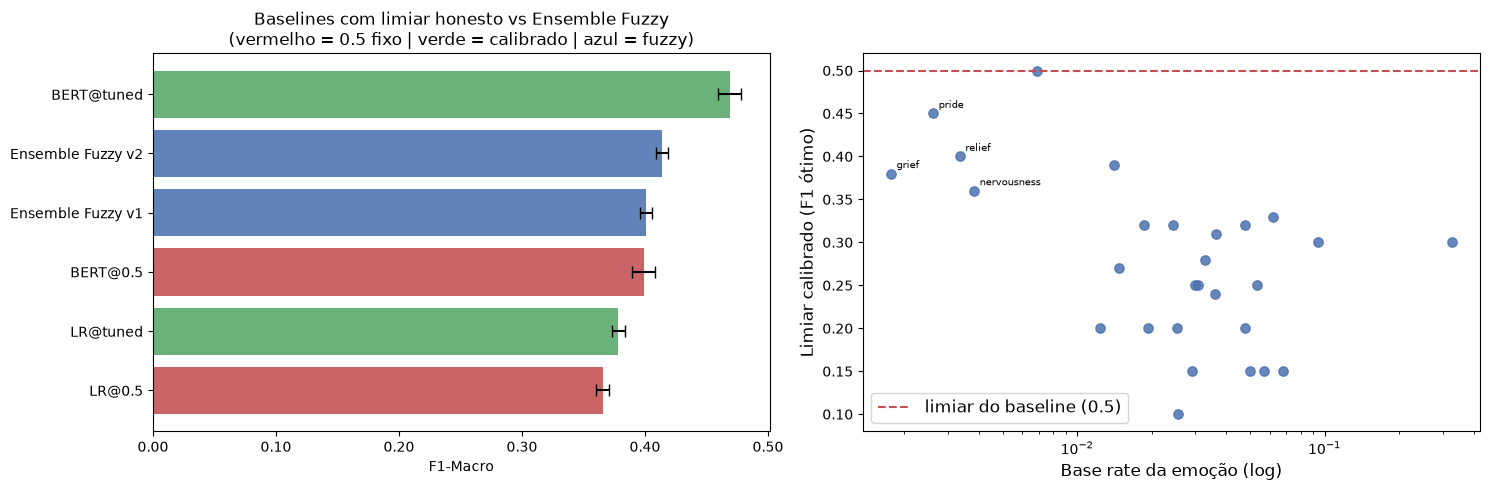

In [10]:
thr_mean = pd.DataFrame(
    {f"fold_{k}": thr_store[k]["BERT"] for k in thr_store}, index=EMOTION_COLS
).mean(axis=1)

df_thr = pd.DataFrame({
    "limiar_calibrado": thr_mean,
    "base_rate": base_rates.reindex(EMOTION_COLS),
}).sort_values("base_rate")

print("===== LIMIAR CALIBRADO POR EMOÇÃO (BERTimbau, média entre folds) =====")
display(df_thr.round(4))
print(f"\nLimiar médio calibrado: {thr_mean.mean():.3f} (vs 0.5 no baseline)")
print(f"Emoções com limiar ótimo < 0.5: {int((thr_mean < 0.5).sum())}/{N_LABELS}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
order = df_final.sort_values("f1_macro")
cols = ["#C44E52" if "@0.5" in i else ("#4C72B0" if "Fuzzy" in i else "#55A868")
        for i in order.index]
ax.barh(order.index, order["f1_macro"], xerr=order["f1_macro_std"],
        capsize=4, color=cols, alpha=0.88)
ax.set_xlabel("F1-Macro")
ax.set_title("Baselines com limiar honesto vs Ensemble Fuzzy\n"
             "(vermelho = 0.5 fixo | verde = calibrado | azul = fuzzy)")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

ax2 = axes[1]
ax2.scatter(df_thr["base_rate"], df_thr["limiar_calibrado"], s=45, color="#4C72B0", alpha=0.85)
ax2.axhline(0.5, color="#C44E52", linestyle="--", label="limiar do baseline (0.5)")
ax2.set_xscale("log")
ax2.set_xlabel("Base rate da emoção (log)", fontsize=12)
ax2.set_ylabel("Limiar calibrado (F1 ótimo)", fontsize=12)
ax2.legend(fontsize=12)
for emo in df_thr.index[:4]:
    ax2.annotate(emo, (df_thr.loc[emo, "base_rate"], df_thr.loc[emo, "limiar_calibrado"]),
                 fontsize=7, xytext=(4, 4), textcoords="offset points")

plt.tight_layout()
plt.savefig(OUT_LIMIAR / "testes_limiar_bert.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
df_thresh.to_csv(OUT_LIMIAR / "efeito_limiar.csv")
df_final.to_csv(OUT_LIMIAR / "comparacao_final_limiar_honesto.csv")
df_thr.to_csv(OUT_LIMIAR / "limiares_calibrados_por_emocao.csv")
pd.DataFrame({name: pd.DataFrame([m["f1_per_label"] for m in v]).mean()
              for name, v in results.items()}).to_csv(OUT_LIMIAR / "f1_por_label_limiar.csv")
np.save(CACHE_LIMIAR / "thresholds_bert.npy",
        np.vstack([thr_store[k]["BERT"] for k in sorted(thr_store)]))

summary = {
    "objetivo": ("Medir o BERTimbau com o MESMO tratamento de limiar que o Ensemble Fuzzy "
                 "recebe (calibrado por emocao, OOF), em vez de 0.5 fixo."),
    "protocolo": ("Para cada outer fold k: limiares calibrados por emocao nas probabilidades "
                  "OOF dos folds j!=k (grade identica a THRESH_GRID do fuzzy), aplicados em "
                  "P_BERT[k]. Nenhum limiar escolhido no fold de teste."),
    "grade_justa": [float(THRESH_GRID.min()), float(THRESH_GRID.max()), int(len(THRESH_GRID))],
    "nota_metrica": ("ROC-AUC e otimista sob desbalanceamento; Average Precision (PR-AUC) e "
                     "a metrica de ranking apropriada para labels raros."),
    "ressalva": ("P_BERT herda do baseline a selecao da melhor epoca pelo F1 no proprio fold "
                 "de teste; como o Ensemble Fuzzy usa o mesmo P_BERT, a comparacao relativa "
                 "nao e afetada, mas o valor absoluto e levemente otimista."),
    "resultados": {name: {
        "f1_macro": f"{d['f1_macro'].mean():.4f} +/- {d['f1_macro'].std():.4f}",
        "precision_macro": f"{d['precision_macro'].mean():.4f}",
        "recall_macro": f"{d['recall_macro'].mean():.4f}",
        "avg_precision_macro": f"{d['avg_precision_macro'].mean():.4f}",
        "roc_auc_macro": f"{d['roc_auc_macro'].mean():.4f}",
    } for name, d in dfs.items()},
    "limiar_medio_bert": float(thr_mean.mean()),
    "n_emocoes_limiar_abaixo_0.5": int((thr_mean < 0.5).sum()),
}
with open(OUT_LIMIAR / "testes_limiar_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("Arquivos exportados para", OUT_LIMIAR.resolve())
print(json.dumps(summary, indent=2, ensure_ascii=False))

Arquivos exportados para C:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\data\out\testes_limiar
{
  "objetivo": "Medir o BERTimbau com o MESMO tratamento de limiar que o Ensemble Fuzzy recebe (calibrado por emocao, OOF), em vez de 0.5 fixo.",
  "protocolo": "Para cada outer fold k: limiares calibrados por emocao nas probabilidades OOF dos folds j!=k (grade identica a THRESH_GRID do fuzzy), aplicados em P_BERT[k]. Nenhum limiar escolhido no fold de teste.",
  "grade_justa": [
    0.05,
    0.95,
    19
  ],
  "nota_metrica": "ROC-AUC e otimista sob desbalanceamento; Average Precision (PR-AUC) e a metrica de ranking apropriada para labels raros.",
  "ressalva": "P_BERT herda do baseline a selecao da melhor epoca pelo F1 no proprio fold de teste; como o Ensemble Fuzzy usa o mesmo P_BERT, a comparacao relativa nao e afetada, mas o valor absoluto e levemente otimista.",
  "resultados": {
    "BERT@0.5": {
      "f1_macro": "0.3990 +/- 0.0095",
      "precisi

# PARTE 1 — Sistema de Inferência Nebulosa (SIN) para emoções

## Setup fuzzy e escolha das emoções-demo

In [12]:
import itertools
import seaborn as sns
import skfuzzy as fuzzy
from skfuzzy import control as ctrl

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 120

OUT_INTERP = Path("../data/out/ensemble_fuzzy_interpretacao")
OUT_INTERP.mkdir(parents=True, exist_ok=True)

FOLD_DEMO = 1   # fold usado para as demonstrações (regras vêm do outer-train dele)

# ── Pontos de decisão (τ) calibrados na Parte 0 ──────────────────
tau_bert = pd.DataFrame({f"f{k}": thr_store[k]["BERT"] for k in thr_store},
                        index=EMOTION_COLS).mean(axis=1)
tau_lr   = pd.DataFrame({f"f{k}": thr_store[k]["LR"]   for k in thr_store},
                        index=EMOTION_COLS).mean(axis=1)

# ── Emoções-demo: melhor e pior F1 (BERT calibrado) ──────────────
f1_lab = pd.DataFrame([m["f1_per_label"] for m in results["BERT@tuned"]]).mean()
EMO_BEST  = f1_lab.idxmax()
EMO_WORST = f1_lab.idxmin()

print("═" * 62)
print("EMOÇÕES SELECIONADAS PARA ANÁLISE APROFUNDADA")
print("═" * 62)
for rot, emo in [("MELHOR", EMO_BEST), ("PIOR", EMO_WORST)]:
    print(f"  {rot:6s}: {emo:15s} | F1={f1_lab[emo]:.4f} | "
          f"base_rate={base_rates[emo]:.4f} | "
          f"τ_BERT={tau_bert[emo]:.2f} | τ_LR={tau_lr[emo]:.2f}")

print("\nRanking completo (F1 por emoção):")
display(pd.DataFrame({
    "F1": f1_lab, "base_rate": base_rates.reindex(f1_lab.index),
    "τ_BERT": tau_bert.reindex(f1_lab.index), "τ_LR": tau_lr.reindex(f1_lab.index),
}).sort_values("F1", ascending=False).round(4))

══════════════════════════════════════════════════════════════
EMOÇÕES SELECIONADAS PARA ANÁLISE APROFUNDADA
══════════════════════════════════════════════════════════════
  MELHOR: gratitude       | F1=0.8955 | base_rate=0.0622 | τ_BERT=0.33 | τ_LR=0.69
  PIOR  : realization     | F1=0.1897 | base_rate=0.0255 | τ_BERT=0.10 | τ_LR=0.73

Ranking completo (F1 por emoção):


,F1,base_rate,τ_BERT,τ_LR
gratitude,0.8955,0.0622,0.33,0.69
love,0.7712,0.0475,0.32,0.40
amusement,0.7611,0.0533,0.25,0.40
remorse,0.6462,0.0123,0.20,0.36
admiration,0.6456,0.0944,0.30,0.50
neutral,0.6454,0.3273,0.30,0.25
fear,0.5755,0.0141,0.39,0.87
optimism,0.5329,0.0364,0.31,0.58
surprise,0.5113,0.0245,0.32,0.95
desire,0.5025,0.0148,0.27,0.49


## Variável de polaridade (contexto léxico)

In [13]:
# ── Polaridade do texto: 3ª entrada, vinda do léxico de sentimento ──
# polaridade = 0.5 + 0.5*(sent_pos − sent_neg)  →  [0=NEGATIVA, 0.5=NEUTRA, 1=POSITIVA]
_sent_fp = find_cached("SENT_lexicon_fold_1.npy")
if _sent_fp is not None:
    SENT_folds = {k: np.load(find_cached(f"SENT_lexicon_fold_{k}.npy")) for k in folds_data}
    print("Sentimento carregado do cache do ensemble.")
else:
    raise FileNotFoundError(
        "SENT_lexicon_fold_*.npy não encontrado em ../data/out/ensemble_fuzzy/cache.\n"
        "Rode a célula de features de sentimento do ensemble_fuzzy, ou troque a 3ª "
        "entrada por 'concordancia' (ver comentário abaixo)."
    )
    # Alternativa sem sentimento — descomente e use no lugar:
    # POL_folds = {k: 1.0 - np.abs(P_LR_folds[k] - P_BERT_folds[k]) for k in folds_data}
    # (vira 'concordancia' entre os modelos, calculável só das probabilidades)

POL_folds = {k: np.clip(0.5 + 0.5 * (S[:, 0] - S[:, 1]), 0.0, 1.0)
             for k, S in SENT_folds.items()}

pol_all = np.concatenate([POL_folds[k] for k in folds_data])
print(f"Polaridade — média={pol_all.mean():.3f} | "
      f"% neutra (0.45–0.55)={100*np.mean((pol_all>=0.45)&(pol_all<=0.55)):.1f}%")
print("Nota: a concentração em 0.5 reflete textos sem palavras do léxico — "
      "é uma limitação real da variável, discutida na conclusão.")

Sentimento carregado do cache do ensemble.
Polaridade — média=0.539 | % neutra (0.45–0.55)=61.4%
Nota: a concentração em 0.5 reflete textos sem palavras do léxico — é uma limitação real da variável, discutida na conclusão.


## Variáveis linguísticas ancoradas em τ

In [14]:
# ══════════════════════════════════════════════════════════════════
# VARIÁVEIS LINGUÍSTICAS
#
# Decisão de projeto central: os termos de p_lr e p_bert são ancorados no
# ponto de decisão τ calibrado para CADA emoção, e não em quantis dos dados.
#
#   BAIXA : evidência abaixo do ponto de decisão
#   MEDIA : evidência na vizinhança do ponto de decisão (zona de dúvida)
#   ALTA  : evidência acima do ponto de decisão
#
# Consequência: o rótulo linguístico é SEMANTICAMENTE VERDADEIRO. Uma partição
# por quantis produziria "ALTA" para p=0.05 em emoções raras — rótulo que mente.
#
# Extremos são TRAPÉZIOS (ombros): μ satura em 1 e permanece. Gaussianas nos
# extremos seriam NÃO-MONÓTONAS (μ cairia para p→1), penalizando justamente as
# predições mais confiantes.
# ══════════════════════════════════════════════════════════════════
U_P    = np.arange(0.0, 1.001, 0.001)   # universo das probabilidades
U_POL  = np.arange(0.0, 1.001, 0.001)   # universo da polaridade
U_PERT = np.arange(0.0, 1.001, 0.001)   # universo da pertinência (saída)

TERMOS_P    = ['BAIXA', 'MEDIA', 'ALTA']
TERMOS_POL  = ['NEGATIVA', 'NEUTRA', 'POSITIVA']
TERMOS_PERT = ['MUITO_BAIXA', 'BAIXA', 'MEDIA', 'ALTA', 'MUITO_ALTA']

def build_prob_antecedent(nome, tau):
    """Antecedente de probabilidade com termos ancorados no ponto de decisão τ."""
    tau = float(np.clip(tau, 0.06, 0.90))
    a = 0.5 * tau                    # início da zona de dúvida
    b = min(1.0, 2.0 * tau)          # fim da zona de dúvida
    var = ctrl.Antecedent(U_P, nome)
    var['BAIXA'] = fuzzy.trapmf(U_P, [0.0, 0.0, a, tau])       # ombro inferior
    var['MEDIA'] = fuzzy.trimf( U_P, [a, tau, b])
    var['ALTA']  = fuzzy.trapmf(U_P, [tau, b, 1.0, 1.0])       # ombro superior
    return var

def build_polaridade():
    var = ctrl.Antecedent(U_POL, 'polaridade')
    var['NEGATIVA'] = fuzzy.trapmf(U_POL, [0.00, 0.00, 0.30, 0.45])
    var['NEUTRA']   = fuzzy.trimf( U_POL, [0.35, 0.50, 0.65])
    var['POSITIVA'] = fuzzy.trapmf(U_POL, [0.55, 0.70, 1.00, 1.00])
    return var

def build_pertinencia():
    """Saída com 5 termos — resolução suficiente sem sacrificar legibilidade."""
    var = ctrl.Consequent(U_PERT, 'pertinencia')
    var['MUITO_BAIXA'] = fuzzy.trapmf(U_PERT, [0.00, 0.00, 0.10, 0.25])
    var['BAIXA']       = fuzzy.trimf( U_PERT, [0.10, 0.28, 0.45])
    var['MEDIA']       = fuzzy.trimf( U_PERT, [0.35, 0.50, 0.65])
    var['ALTA']        = fuzzy.trimf( U_PERT, [0.55, 0.72, 0.90])
    var['MUITO_ALTA']  = fuzzy.trapmf(U_PERT, [0.75, 0.90, 1.00, 1.00])
    return var

def mu(universo, mf, valores):
    """Pertinência vetorizada (rápida, para os 43k pontos de calibração)."""
    return np.interp(np.asarray(valores, dtype=float), universo, mf)

print("Construtores de variáveis linguísticas prontos.")

Construtores de variáveis linguísticas prontos.


## Gráficos das variáveis (o "retrato" do sistema)

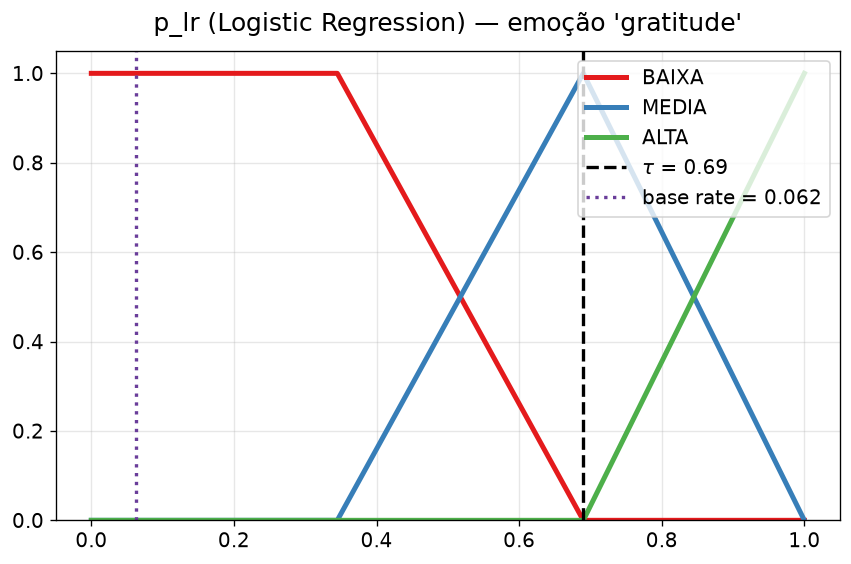

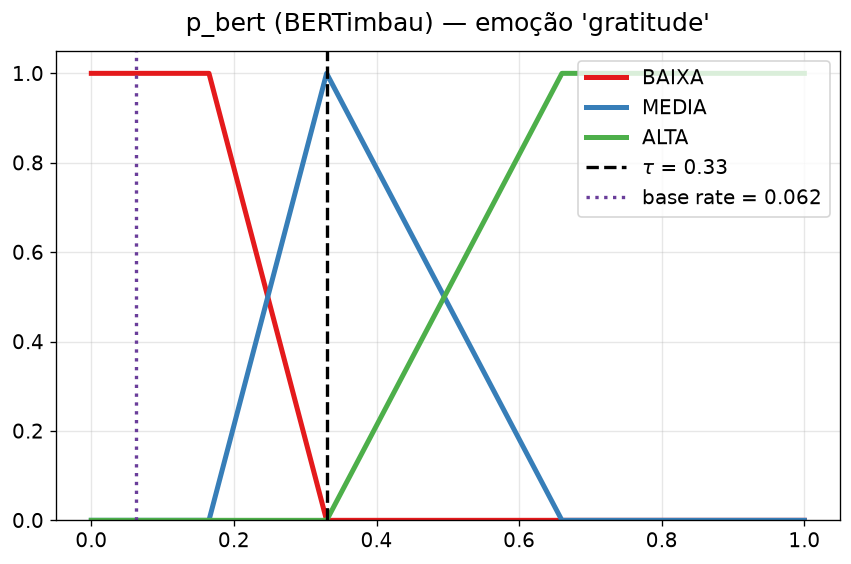

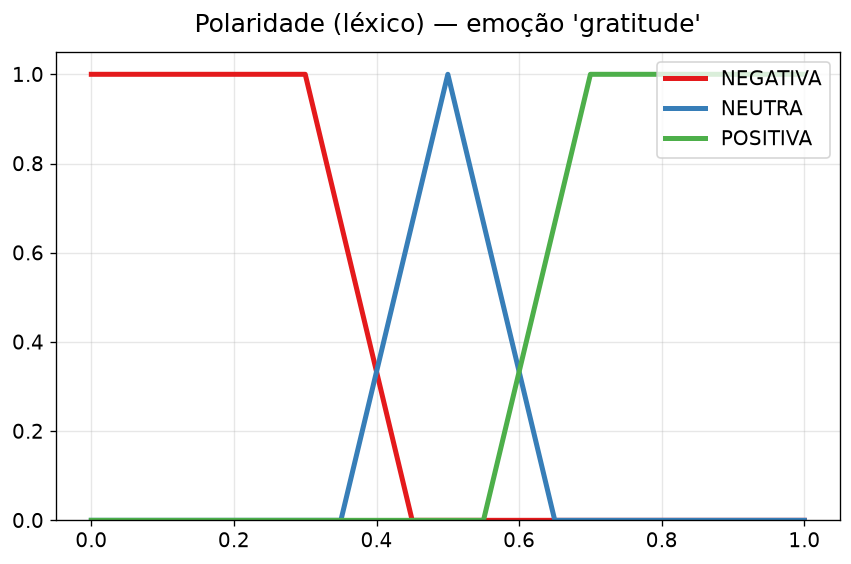

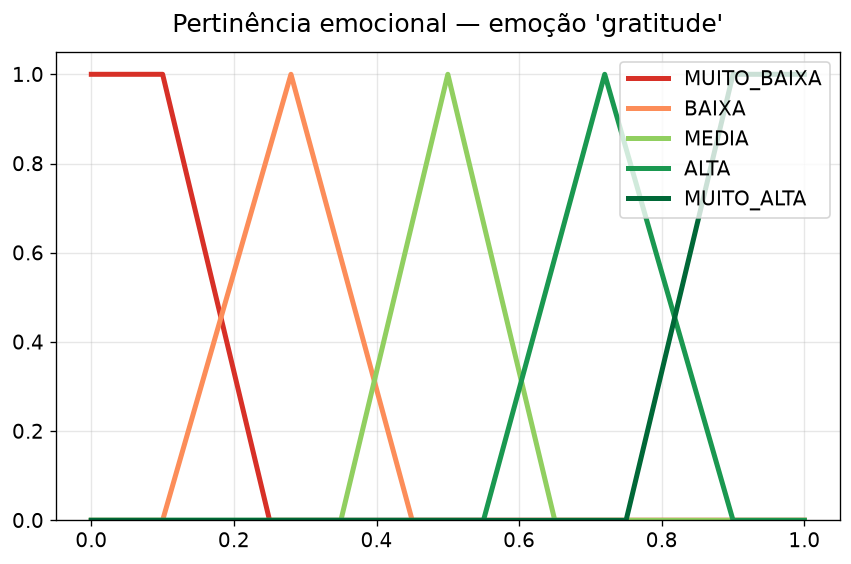

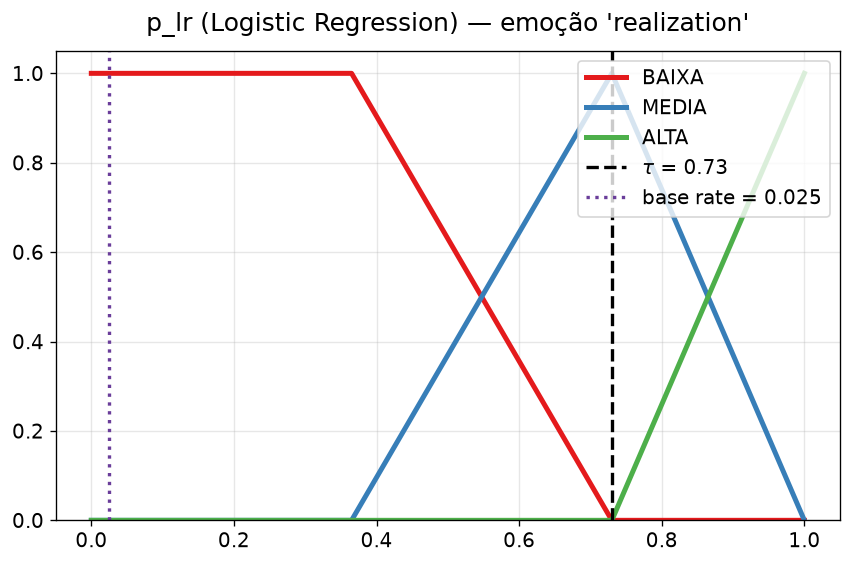

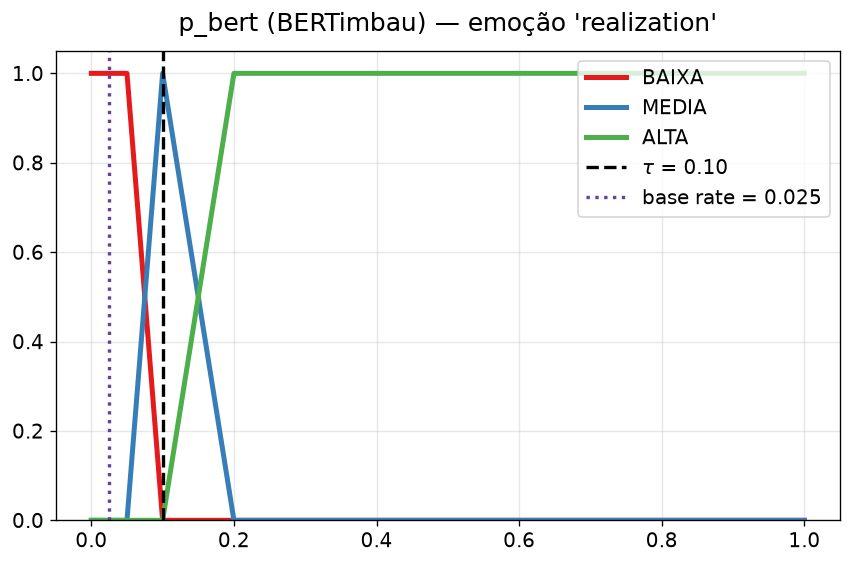

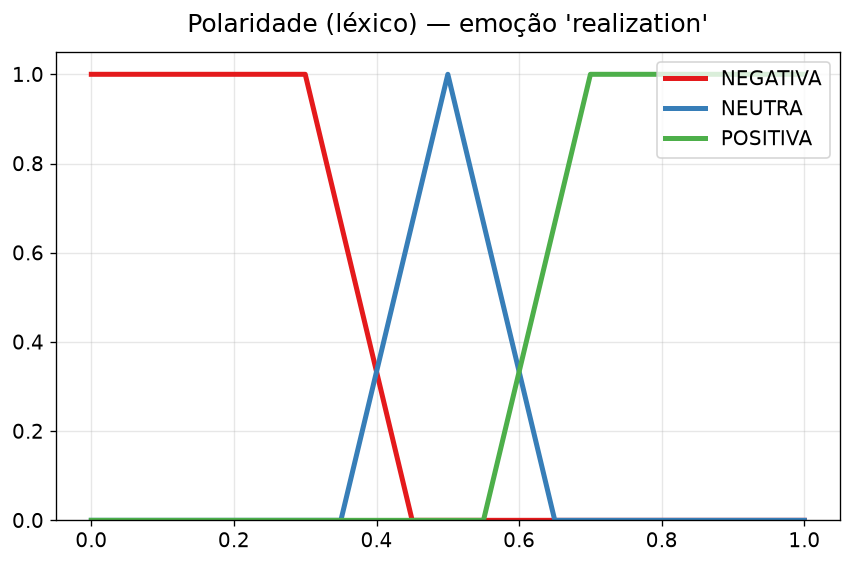

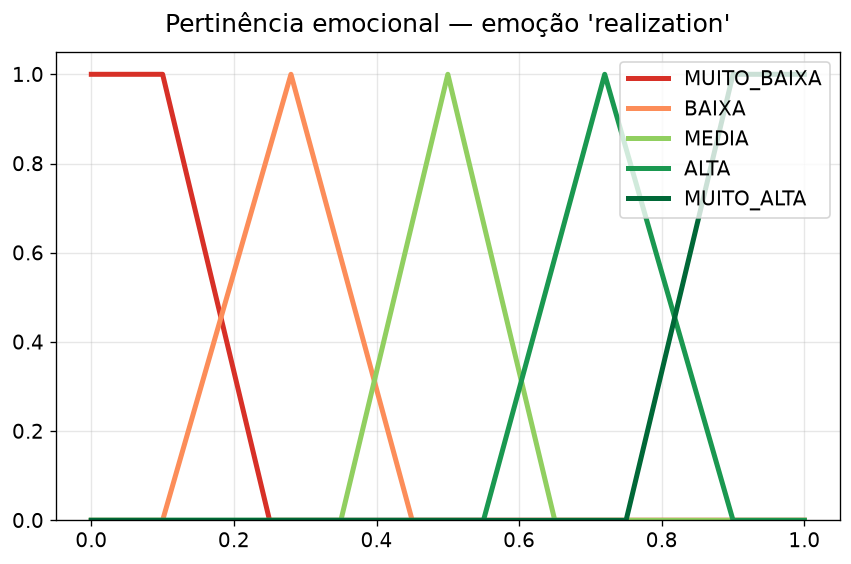

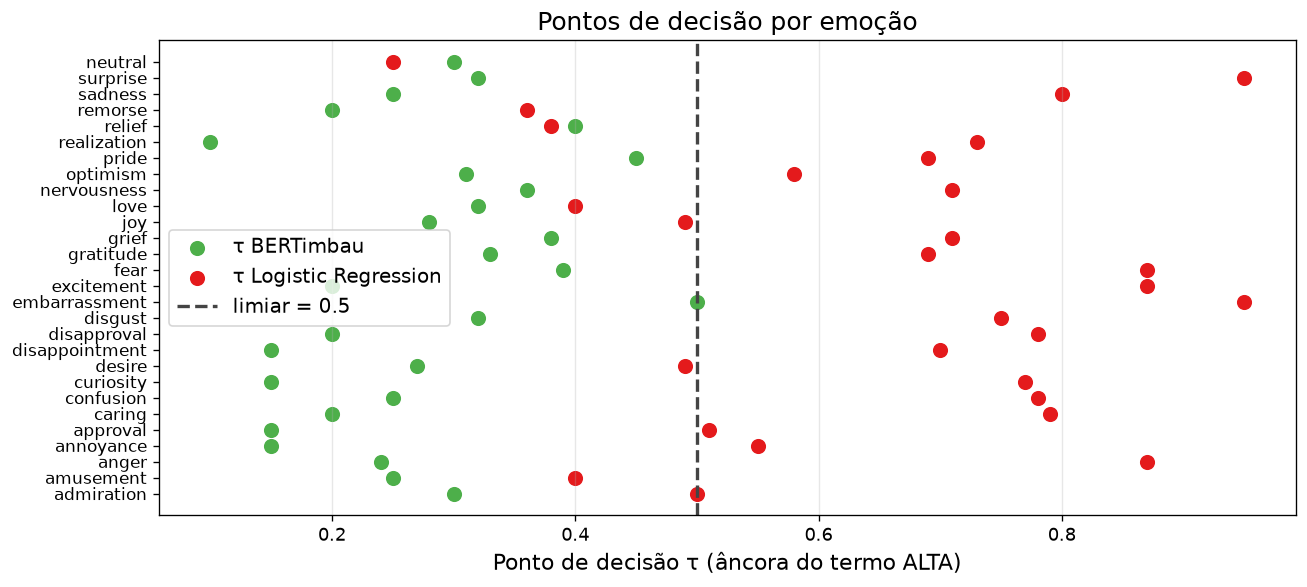

τ médio BERTimbau: 0.276 | τ médio LR: 0.654
Leitura: o LR exige evidência MAIS ALTA para a mesma decisão — efeito do SMOTE, que reequilibra o treino e infla as probabilidades. O BERTimbau, treinado com CB-Loss sobre a distribuição real, decide bem abaixo de 0.5.


In [15]:
# ============================================================
# Paletas de cores
# ============================================================

# Variáveis linguísticas (ColorBrewer Set1)
# Alto contraste e sem amarelo apagado.
PALETA_VARIAVEIS = [
    "#E41A1C",  # vermelho
    "#377EB8",  # azul
    "#4DAF4A",  # verde
    "#984EA3",  # roxo
    "#FF7F00",  # laranja
]

# Pertinência (mantive a que ficou boa)
PALETA_PERT = [
    "#D73027",
    "#FC8D59",
    "#91CF60",
    "#1A9850",
    "#006837",
]

# ============================================================
# Gráficos das variáveis linguísticas
# ============================================================

def plot_variaveis_emocao(emo):

    v_lr = build_prob_antecedent("p_lr", tau_lr[emo])
    v_bert = build_prob_antecedent("p_bert", tau_bert[emo])
    v_pol = build_polaridade()
    v_pert = build_pertinencia()

    graficos = [
        (
            v_lr,
            U_P,
            TERMOS_P,
            "p_lr (Logistic Regression)",
            tau_lr[emo],
            "variavel_lr",
        ),
        (
            v_bert,
            U_P,
            TERMOS_P,
            "p_bert (BERTimbau)",
            tau_bert[emo],
            "variavel_bert",
        ),
        (
            v_pol,
            U_POL,
            TERMOS_POL,
            "Polaridade (léxico)",
            None,
            "variavel_polaridade",
        ),
    ]

    # ========================================================
    # Um gráfico para cada variável linguística
    # ========================================================

    for var, universo, termos, titulo, tau, nome in graficos:

        fig, ax = plt.subplots(figsize=(7.2, 4.8))

        cores = PALETA_VARIAVEIS[: len(termos)]

        for termo, cor in zip(termos, cores):
            ax.plot(
                universo,
                var[termo].mf,
                color=cor,
                linewidth=3,
                label=termo,
            )

        if tau is not None:

            ax.axvline(
                tau,
                color="black",
                linestyle="--",
                linewidth=2,
                label=fr"$\tau$ = {tau:.2f}",
            )

            ax.axvline(
                base_rates[emo],
                color="#6A3D9A",
                linestyle=":",
                linewidth=2,
                label=f"base rate = {base_rates[emo]:.3f}",
            )

        ax.set_title(
            f"{titulo} — emoção '{emo}'",
            fontsize=15,
            pad=12,
        )

        ax.set_ylim(0, 1.05)

        ax.grid(alpha=0.30)

        ax.tick_params(labelsize=12)

        ax.legend(
            fontsize=12,
            frameon=True,
            loc="upper right",
        )

        plt.tight_layout()

        plt.savefig(
            OUT_INTERP / f"{nome}_{emo}.png",
            dpi=180,
            bbox_inches="tight",
        )

        plt.show()

    # ========================================================
    # Pertinência (mantida separada)
    # ========================================================

    fig, ax = plt.subplots(figsize=(7.2, 4.8))

    cores = PALETA_PERT[: len(TERMOS_PERT)]

    for termo, cor in zip(TERMOS_PERT, cores):
        ax.plot(
            U_PERT,
            v_pert[termo].mf,
            color=cor,
            linewidth=3,
            label=termo,
        )

    ax.set_title(
        f"Pertinência emocional — emoção '{emo}'",
        fontsize=15,
        pad=12,
    )

    ax.set_ylim(0, 1.05)

    ax.grid(alpha=0.30)

    ax.tick_params(labelsize=12)

    ax.legend(
        fontsize=12,
        frameon=True,
        loc="upper right",
    )

    plt.tight_layout()

    plt.savefig(
        OUT_INTERP / f"pertinencia_{emo}.png",
        dpi=180,
        bbox_inches="tight",
    )

    plt.show()


# ============================================================
# Melhor e pior emoção
# ============================================================

for emo in [EMO_BEST, EMO_WORST]:
    plot_variaveis_emocao(emo)


# ============================================================
# Comparação dos τ
# ============================================================

fig, ax = plt.subplots(figsize=(11, 5))

ax.scatter(
    tau_bert.values,
    np.arange(N_LABELS),
    color="#4DAF4A",
    s=65,
    label="τ BERTimbau",
)

ax.scatter(
    tau_lr.values,
    np.arange(N_LABELS),
    color="#E41A1C",
    s=65,
    label="τ Logistic Regression",
)

ax.axvline(
    0.5,
    color="#444444",
    linestyle="--",
    linewidth=2,
    label="limiar = 0.5",
)

ax.set_title(
    "Pontos de decisão por emoção",
    fontsize=15,
)

ax.set_xlabel(
    "Ponto de decisão τ (âncora do termo ALTA)",
    fontsize=13,
)

ax.set_yticks(np.arange(N_LABELS))
ax.set_yticklabels(
    EMOTION_COLS,
    fontsize=10,
)

ax.tick_params(axis="x", labelsize=11)

ax.grid(
    axis="x",
    alpha=0.30,
)

ax.legend(
    fontsize=12,
    frameon=True,
)

plt.tight_layout()

plt.savefig(
    OUT_INTERP / "taus_por_emocao.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print(
    f"τ médio BERTimbau: {tau_bert.mean():.3f} | "
    f"τ médio LR: {tau_lr.mean():.3f}"
)

print(
    "Leitura: o LR exige evidência MAIS ALTA para a mesma decisão — efeito do "
    "SMOTE, que reequilibra o treino e infla as probabilidades. "
    "O BERTimbau, treinado com CB-Loss sobre a distribuição real, "
    "decide bem abaixo de 0.5."
)

## MAF: método do especialista (conhecimento de domínio)

In [16]:
# ══════════════════════════════════════════════════════════════════
# MÉTODO 1 — MAF do ESPECIALISTA (conhecimento de domínio, sem dados)
#
# Heurísticas codificadas:
#   ↑ p_bert  →  ↑ pertinência  (peso DOBRO: é o modelo mais preciso)
#   ↑ p_lr    →  ↑ pertinência  (peso simples: alto recall, baixa precisão)
#   polaridade CONCORDA com a valência da emoção  →  reforça
#   polaridade DISCORDA da valência               →  atenua
# ══════════════════════════════════════════════════════════════════
VALENCIA = {
    'admiration': +1, 'amusement': +1, 'approval': +1, 'caring': +1, 'desire': +1,
    'excitement': +1, 'gratitude': +1, 'joy': +1, 'love': +1, 'optimism': +1,
    'pride': +1, 'relief': +1,
    'anger': -1, 'annoyance': -1, 'disappointment': -1, 'disapproval': -1,
    'disgust': -1, 'embarrassment': -1, 'fear': -1, 'grief': -1,
    'nervousness': -1, 'remorse': -1, 'sadness': -1,
    'confusion': 0, 'curiosity': 0, 'realization': 0, 'surprise': 0, 'neutral': 0,
}

def maf_especialista(i_lr, i_bert, i_pol, emo):
    """Índices 0/1/2 (BAIXA/MEDIA/ALTA) → índice 0..4 do termo de saída."""
    bruto = i_lr + 2 * i_bert                 # 0..6  (BERT pesa o dobro)
    idx = bruto * 4.0 / 6.0                   # reescala p/ 0..4
    val = VALENCIA.get(emo, 0)
    if val != 0:
        sinal_pol = i_pol - 1                 # -1 NEG | 0 NEU | +1 POS
        idx += 0.5 * sinal_pol * val          # concorda reforça, discorda atenua
    return int(np.clip(round(idx), 0, 4))


def gerar_maf_especialista(emo):
    linhas = []
    for i_lr, i_bert, i_pol in itertools.product(range(3), range(3), range(3)):
        linhas.append({
            't_lr': TERMOS_P[i_lr], 't_bert': TERMOS_P[i_bert], 't_pol': TERMOS_POL[i_pol],
            't_pert': TERMOS_PERT[maf_especialista(i_lr, i_bert, i_pol, emo)],
            'origem': 'especialista', 'suporte': np.nan, 'conf': np.nan,
        })
    return pd.DataFrame(linhas)

df_esp_best = gerar_maf_especialista(EMO_BEST)
print(f"Regras do especialista para '{EMO_BEST}': {len(df_esp_best)} (3×3×3 = cobertura total)")
display(df_esp_best.head(9))

Regras do especialista para 'gratitude': 27 (3×3×3 = cobertura total)


,t_lr,t_bert,t_pol,t_pert,origem,suporte,conf
0,BAIXA,BAIXA,NEGATIVA,MUITO_BAIXA,especialista,NaN,NaN
1,BAIXA,BAIXA,NEUTRA,MUITO_BAIXA,especialista,NaN,NaN
2,BAIXA,BAIXA,POSITIVA,MUITO_BAIXA,especialista,NaN,NaN
3,BAIXA,MEDIA,NEGATIVA,BAIXA,especialista,NaN,NaN
4,BAIXA,MEDIA,NEUTRA,BAIXA,especialista,NaN,NaN
5,BAIXA,MEDIA,POSITIVA,MEDIA,especialista,NaN,NaN
6,BAIXA,ALTA,NEGATIVA,MEDIA,especialista,NaN,NaN
7,BAIXA,ALTA,NEUTRA,ALTA,especialista,NaN,NaN
8,BAIXA,ALTA,POSITIVA,ALTA,especialista,NaN,NaN


## MAF: método Wang–Mendel (extraída dos dados)

In [17]:
# ══════════════════════════════════════════════════════════════════
# MÉTODO 2 — WANG–MENDEL (regras extraídas dos dados OOF)
#
# Cada amostra vota na célula (t_lr, t_bert, t_pol) do seu termo dominante,
# com peso = grau de disparo. O consequente da célula sai da razão entre
# massa positiva e negativa. Células sem dados são preenchidas pelo especialista
# (híbrido dados + conhecimento — como no trabalho de referência).
# ══════════════════════════════════════════════════════════════════
def fuzzificar_bulk(emo, p_lr_vals, p_bert_vals, pol_vals):
    v_lr   = build_prob_antecedent('p_lr',   tau_lr[emo])
    v_bert = build_prob_antecedent('p_bert', tau_bert[emo])
    v_pol  = build_polaridade()
    M_lr   = np.column_stack([mu(U_P,   v_lr[t].mf,   p_lr_vals)   for t in TERMOS_P])
    M_bert = np.column_stack([mu(U_P,   v_bert[t].mf, p_bert_vals) for t in TERMOS_P])
    M_pol  = np.column_stack([mu(U_POL, v_pol[t].mf,  pol_vals)    for t in TERMOS_POL])
    return M_lr, M_bert, M_pol


def wang_mendel(emo, fold_demo=FOLD_DEMO, media_ratio=1.15):
    """Extrai a MAF dos dados do outer-train do fold_demo."""
    ks = [k for k in folds_data if k != fold_demo]
    p_lr   = np.vstack([P_LR_folds[k]   for k in ks])[:, EMOTION_COLS.index(emo)]
    p_bert = np.vstack([P_BERT_folds[k] for k in ks])[:, EMOTION_COLS.index(emo)]
    pol    = np.concatenate([POL_folds[k] for k in ks])
    y      = np.vstack([Y_folds[k] for k in ks])[:, EMOTION_COLS.index(emo)]

    M_lr, M_bert, M_pol = fuzzificar_bulk(emo, p_lr, p_bert, pol)
    i_lr, i_bert, i_pol = M_lr.argmax(1), M_bert.argmax(1), M_pol.argmax(1)
    grau = M_lr.max(1) * M_bert.max(1) * M_pol.max(1)      # t-norma produto

    # peso suave p/ a classe positiva (o τ já faz o balanceamento grosso)
    pw = float(np.clip(np.sqrt((1 - base_rates[emo]) / max(base_rates[emo], 1e-6)), 1.0, 4.0))
    w = grau * np.where(y == 1, pw, 1.0)

    codigo = i_lr * 9 + i_bert * 3 + i_pol
    linhas = []
    for cod in range(27):
        m = codigo == cod
        a, b, c = cod // 9, (cod % 9) // 3, cod % 3
        s_pos, s_neg = w[m & (y == 1)].sum(), w[m & (y == 0)].sum()
        tot, n_cru = s_pos + s_neg, int(m.sum())

        if tot <= 0 or n_cru < 10:                       # célula vazia/rala
            t_pert = TERMOS_PERT[maf_especialista(a, b, c, emo)]
            origem, conf = 'especialista (célula sem dados)', np.nan
        else:
            r = s_pos / tot
            if   r > 0.70: idx = 4
            elif r > 0.55: idx = 3
            elif r > 0.40: idx = 2
            elif r > 0.20: idx = 1
            else:          idx = 0
            t_pert, origem, conf = TERMOS_PERT[idx], 'dados', r

        linhas.append({'t_lr': TERMOS_P[a], 't_bert': TERMOS_P[b], 't_pol': TERMOS_POL[c],
                       't_pert': t_pert, 'origem': origem,
                       'suporte': round(tot, 1), 'n_amostras': n_cru,
                       'conf': None if conf != conf else round(conf, 3)})
    return pd.DataFrame(linhas)


df_wm_best  = wang_mendel(EMO_BEST)
df_wm_worst = wang_mendel(EMO_WORST)

for emo, df in [(EMO_BEST, df_wm_best), (EMO_WORST, df_wm_worst)]:
    n_dados = (df['origem'] == 'dados').sum()
    print(f"\n'{emo}': {n_dados}/27 células com suporte de dados, "
          f"{27-n_dados}/27 preenchidas pelo especialista")
    print(f"  Distribuição dos consequentes: {df['t_pert'].value_counts().to_dict()}")

print(f"\n── Base de regras Wang–Mendel para '{EMO_BEST}' (top 10 por suporte) ──")
display(df_wm_best.sort_values('suporte', ascending=False).head(10))


'gratitude': 19/27 células com suporte de dados, 8/27 preenchidas pelo especialista
  Distribuição dos consequentes: {'MUITO_ALTA': 12, 'MEDIA': 5, 'MUITO_BAIXA': 4, 'ALTA': 4, 'BAIXA': 2}

'realization': 25/27 células com suporte de dados, 2/27 preenchidas pelo especialista
  Distribuição dos consequentes: {'BAIXA': 8, 'MUITO_BAIXA': 6, 'MEDIA': 5, 'ALTA': 5, 'MUITO_ALTA': 3}

── Base de regras Wang–Mendel para 'gratitude' (top 10 por suporte) ──


,t_lr,t_bert,t_pol,t_pert,origem,suporte,n_amostras,conf
1,BAIXA,BAIXA,NEUTRA,MUITO_BAIXA,dados,26634.6,26444,0.015
2,BAIXA,BAIXA,POSITIVA,MUITO_BAIXA,dados,9281.4,8940,0.063
26,ALTA,ALTA,POSITIVA,MUITO_ALTA,dados,7249.1,1986,0.993
0,BAIXA,BAIXA,NEGATIVA,MUITO_BAIXA,dados,5222.7,5204,0.015
25,ALTA,ALTA,NEUTRA,MUITO_ALTA,dados,523.1,164,0.983
17,MEDIA,ALTA,POSITIVA,MUITO_ALTA,dados,178.6,82,0.938
24,ALTA,ALTA,NEGATIVA,MUITO_ALTA,dados,150.4,47,0.982
7,BAIXA,ALTA,NEUTRA,MUITO_ALTA,dados,139.5,58,0.838
11,MEDIA,BAIXA,POSITIVA,MEDIA,dados,119.2,110,0.409
8,BAIXA,ALTA,POSITIVA,MUITO_ALTA,dados,114.3,58,0.785


## Heatmaps das MAFs (melhor vs pior emoção, especialista vs dados)

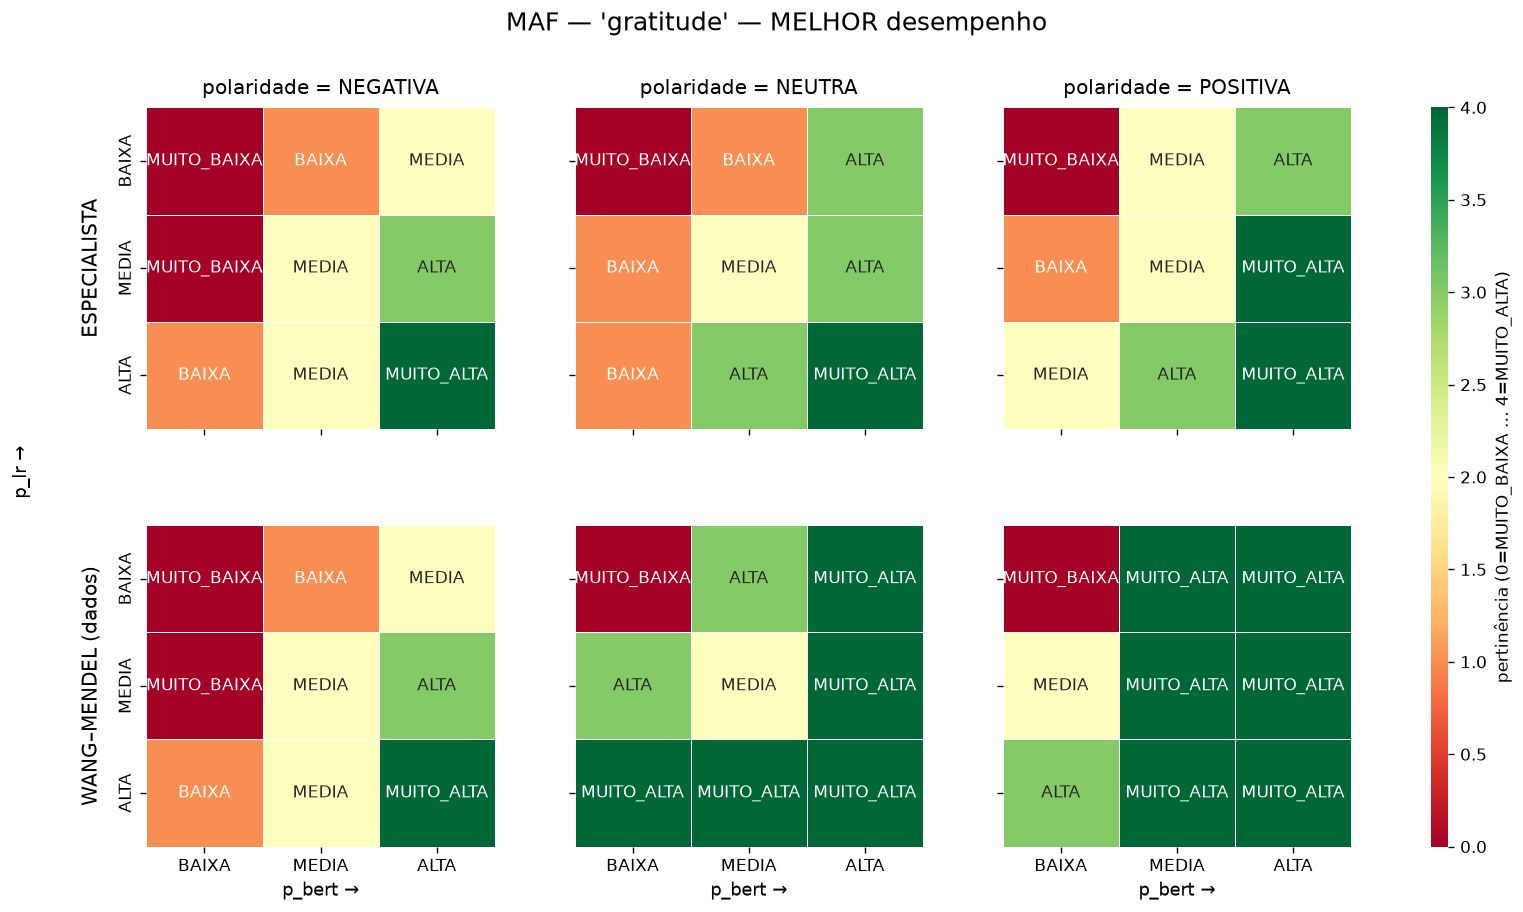

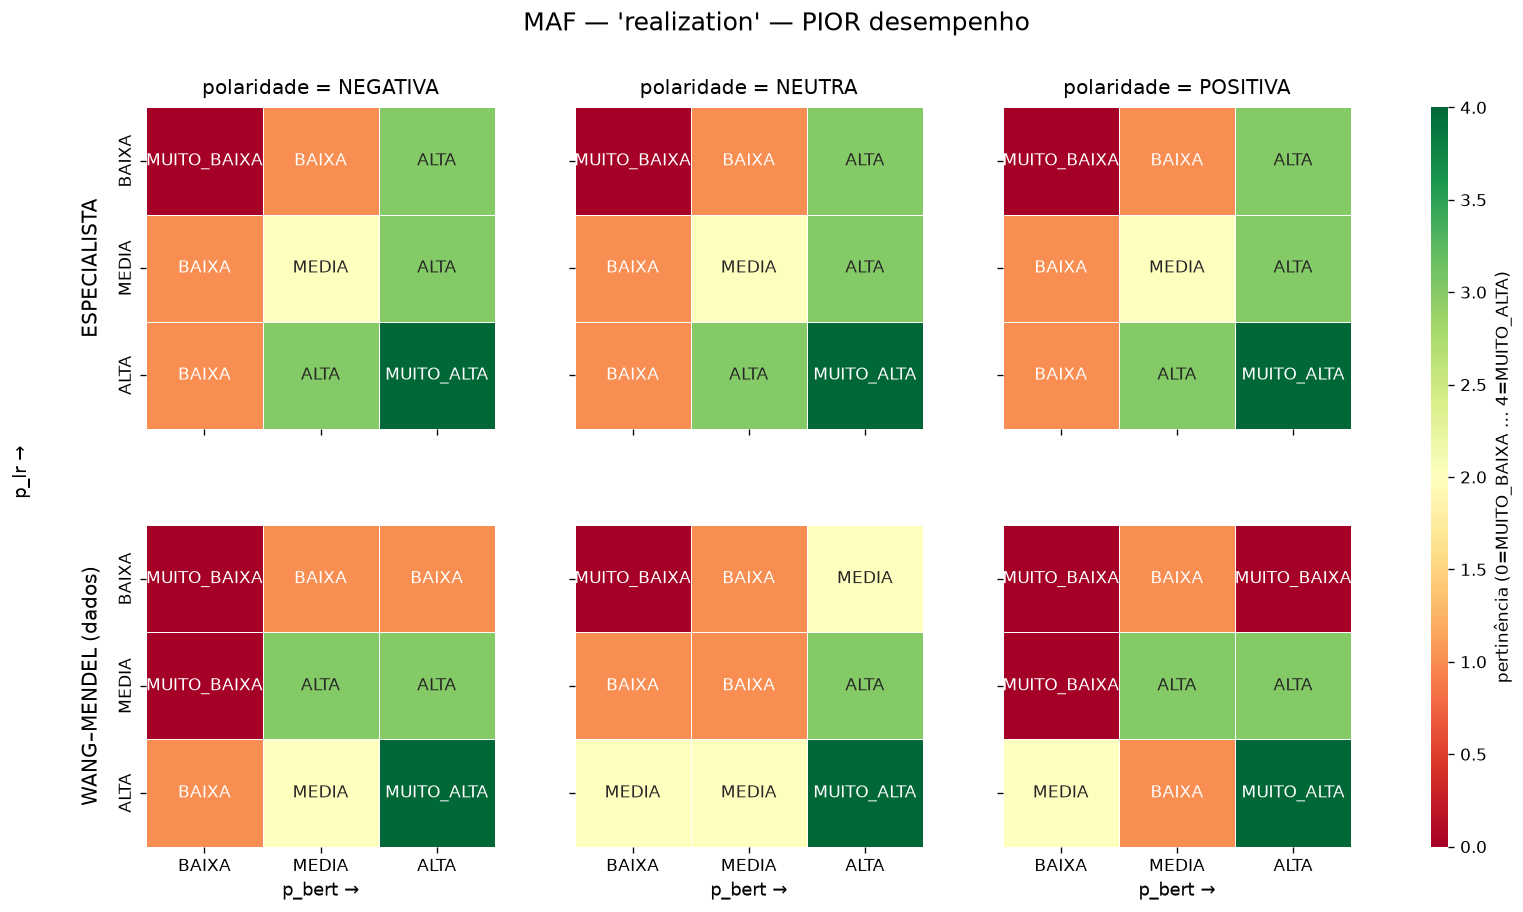

══════════════════════════════════════════════════════════════
CONCORDÂNCIA ESPECIALISTA × DADOS
══════════════════════════════════════════════════════════════
  gratitude      : 15/27 células idênticas | distância média = 0.67 termos
  realization    : 14/27 células idênticas | distância média = 0.63 termos


In [18]:
ESCALA_PERT = {t: i for i, t in enumerate(TERMOS_PERT)}

def maf_para_df(df_reg, t_pol):
    """Tabela p_lr (linhas) × p_bert (colunas) para um termo de polaridade."""
    out = pd.DataFrame(index=TERMOS_P, columns=TERMOS_P, dtype=object)
    for t_lr in TERMOS_P:
        for t_bert in TERMOS_P:
            m = df_reg[
                (df_reg['t_lr'] == t_lr) &
                (df_reg['t_bert'] == t_bert) &
                (df_reg['t_pol'] == t_pol)
            ]
            out.loc[t_lr, t_bert] = m['t_pert'].values[0] if len(m) else '?'
    return out


def plot_mafs(emo, df_dados, titulo_extra=""):
    df_esp = gerar_maf_especialista(emo)

    fig = plt.figure(figsize=(14, 8))
    gs = fig.add_gridspec(2, 4, width_ratios=[1, 1, 1, 0.05],
                          wspace=0.30, hspace=0.30)
    axes = np.array([[fig.add_subplot(gs[r, c]) for c in range(3)] for r in range(2)])
    cax = fig.add_subplot(gs[:, 3])

    fig.suptitle(f"MAF — '{emo}' {titulo_extra}", fontsize=15, y=0.98)

    for col, t_pol in enumerate(TERMOS_POL):
        for row, (df_reg, metodo) in enumerate([(df_esp, 'ESPECIALISTA'),
                                                (df_dados, 'WANG–MENDEL (dados)')]):
            ax = axes[row, col]
            tab = maf_para_df(df_reg, t_pol)
            num = tab.replace(ESCALA_PERT).apply(pd.to_numeric, errors='coerce')
            primeiro = (row == 0 and col == 2)

            sns.heatmap(num, annot=tab.values, fmt='', cmap='RdYlGn',
                        vmin=0, vmax=4, linewidths=0.6, ax=ax,
                        cbar=primeiro, cbar_ax=cax if primeiro else None,
                        annot_kws={"fontsize": 10})

            # coluna → polaridade (só no topo)
            if row == 0:
                ax.set_title(f"polaridade = {t_pol}", fontsize=12, pad=8)
            # linha → método (só à esquerda)
            ax.set_ylabel(metodo if col == 0 else "", fontsize=12, labelpad=10)
            # eixos só nas bordas
            ax.set_xlabel("p_bert →" if row == 1 else "", fontsize=11)
            if col > 0:
                ax.set_yticklabels([])
            if row == 0:
                ax.set_xticklabels([])
            ax.tick_params(axis="both", labelsize=10)

    # rótulo do eixo p_lr, uma vez só
    fig.text(0.045, 0.5, "p_lr →", rotation=90, va='center', fontsize=11)
    cax.set_ylabel("pertinência (0=MUITO_BAIXA … 4=MUITO_ALTA)", fontsize=10)

    plt.savefig(OUT_INTERP / f"maf_{emo}.png", dpi=300, bbox_inches="tight")
    plt.show()


plot_mafs(EMO_BEST, df_wm_best, "— MELHOR desempenho")
plot_mafs(EMO_WORST, df_wm_worst, "— PIOR desempenho")


# ── Concordância entre as duas MAFs ──────────────────────────────
print("═" * 62)
print("CONCORDÂNCIA ESPECIALISTA × DADOS")
print("═" * 62)

for emo, df_d in [(EMO_BEST, df_wm_best), (EMO_WORST, df_wm_worst)]:
    df_e = gerar_maf_especialista(emo)
    chave = ['t_lr', 't_bert', 't_pol']
    j = df_e.merge(df_d, on=chave, suffixes=('_esp', '_dados'))

    iguais = (j['t_pert_esp'] == j['t_pert_dados']).sum()
    dist = (
        j['t_pert_esp'].map(ESCALA_PERT)
        - j['t_pert_dados'].map(ESCALA_PERT)
    ).abs().mean()

    print(
        f"  {emo:15s}: {iguais}/27 células idênticas | "
        f"distância média = {dist:.2f} termos"
    )

## Verificação de sanidade (o teste que a v2 reprovaria)

In [19]:
# ══════════════════════════════════════════════════════════════════
# AUDITORIA SEMÂNTICA — as regras dizem o que os rótulos prometem?
#
# Este teste reprovaria a versão anterior do ensemble, cuja regra de maior
# suporte era:  "SE p_lr é ALTO E p_bert é ALTO ENTÃO pertinência é BAIXA"
# — consequência de ancorar os termos em quantis dos dados.
# ══════════════════════════════════════════════════════════════════
print("═" * 62)
print("TESTE DE MONOTONICIDADE DAS REGRAS")
print("═" * 62)
for emo, df in [(EMO_BEST, df_wm_best), (EMO_WORST, df_wm_worst)]:
    print(f"\n── {emo} ──")
    for t_pol in TERMOS_POL:
        tab = maf_para_df(df, t_pol).replace(ESCALA_PERT).apply(pd.to_numeric)
        mono_lr   = bool((tab.diff(axis=0).fillna(0) >= 0).all().all())
        mono_bert = bool((tab.diff(axis=1).fillna(0) >= 0).all().all())
        print(f"  polaridade={t_pol:9s} | ↑p_lr ⇒ ↑pertinência: {mono_lr} | "
              f"↑p_bert ⇒ ↑pertinência: {mono_bert}")

    canto = df[(df.t_lr == 'ALTA') & (df.t_bert == 'ALTA')]
    print(f"  Células 'ambos ALTA' → consequentes: {canto['t_pert'].tolist()}")
    ok = all(t in ('ALTA', 'MUITO_ALTA', 'MEDIA') for t in canto['t_pert'])
    print(f"  ✓ Coerente" if ok else "  ✗ INCOERENTE — rótulo não corresponde à semântica")

══════════════════════════════════════════════════════════════
TESTE DE MONOTONICIDADE DAS REGRAS
══════════════════════════════════════════════════════════════

── gratitude ──
  polaridade=NEGATIVA  | ↑p_lr ⇒ ↑pertinência: True | ↑p_bert ⇒ ↑pertinência: True
  polaridade=NEUTRA    | ↑p_lr ⇒ ↑pertinência: False | ↑p_bert ⇒ ↑pertinência: False
  polaridade=POSITIVA  | ↑p_lr ⇒ ↑pertinência: True | ↑p_bert ⇒ ↑pertinência: True
  Células 'ambos ALTA' → consequentes: ['MUITO_ALTA', 'MUITO_ALTA', 'MUITO_ALTA']
  ✓ Coerente

── realization ──
  polaridade=NEGATIVA  | ↑p_lr ⇒ ↑pertinência: False | ↑p_bert ⇒ ↑pertinência: True
  polaridade=NEUTRA    | ↑p_lr ⇒ ↑pertinência: True | ↑p_bert ⇒ ↑pertinência: True
  polaridade=POSITIVA  | ↑p_lr ⇒ ↑pertinência: False | ↑p_bert ⇒ ↑pertinência: False
  Células 'ambos ALTA' → consequentes: ['MUITO_ALTA', 'MUITO_ALTA', 'MUITO_ALTA']
  ✓ Coerente


## Construção do FIS (skfuzzy control)

In [20]:
# ══════════════════════════════════════════════════════════════════
# SISTEMA DE INFERÊNCIA — Mamdani via skfuzzy.control
# ══════════════════════════════════════════════════════════════════
_FIS_CACHE = {}

def criar_fis(emo, df_reg, defuzz='centroid'):
    chave = (emo, defuzz, id(df_reg))
    if chave in _FIS_CACHE:
        return _FIS_CACHE[chave]

    v_lr   = build_prob_antecedent('p_lr',   tau_lr[emo])
    v_bert = build_prob_antecedent('p_bert', tau_bert[emo])
    v_pol  = build_polaridade()
    v_pert = build_pertinencia()
    v_pert.defuzzify_method = defuzz

    regras = [ctrl.Rule(v_lr[r['t_lr']] & v_bert[r['t_bert']] & v_pol[r['t_pol']],
                        v_pert[r['t_pert']])
              for _, r in df_reg.iterrows()]

    sim = ctrl.ControlSystemSimulation(ctrl.ControlSystem(regras))
    _FIS_CACHE[chave] = (sim, (v_lr, v_bert, v_pol, v_pert))
    return _FIS_CACHE[chave]

def inferir(emo, df_reg, p_lr_v, p_bert_v, pol_v, defuzz='centroid'):
    sim, _ = criar_fis(emo, df_reg, defuzz)
    sim.input['p_lr']       = float(np.clip(p_lr_v, 0, 1))
    sim.input['p_bert']     = float(np.clip(p_bert_v, 0, 1))
    sim.input['polaridade'] = float(np.clip(pol_v, 0, 1))
    sim.compute()
    return float(sim.output['pertinencia'])

print("FIS pronto. Teste rápido:")
print(f"  {EMO_BEST} | p_lr=0.8, p_bert=0.9, pol=0.9 → "
      f"pertinência = {inferir(EMO_BEST, df_wm_best, 0.8, 0.9, 0.9):.3f}")
print(f"  {EMO_BEST} | p_lr=0.05, p_bert=0.02, pol=0.5 → "
      f"pertinência = {inferir(EMO_BEST, df_wm_best, 0.05, 0.02, 0.5):.3f}")

FIS pronto. Teste rápido:
  gratitude | p_lr=0.8, p_bert=0.9, pol=0.9 → pertinência = 0.897
  gratitude | p_lr=0.05, p_bert=0.02, pol=0.5 → pertinência = 0.093


## Visualização da ativação (estilo .view(sim=FIS))

TEXTO REAL: "obrigada realmente aprecio sua resposta"
Rótulo verdadeiro para gratitude: 1



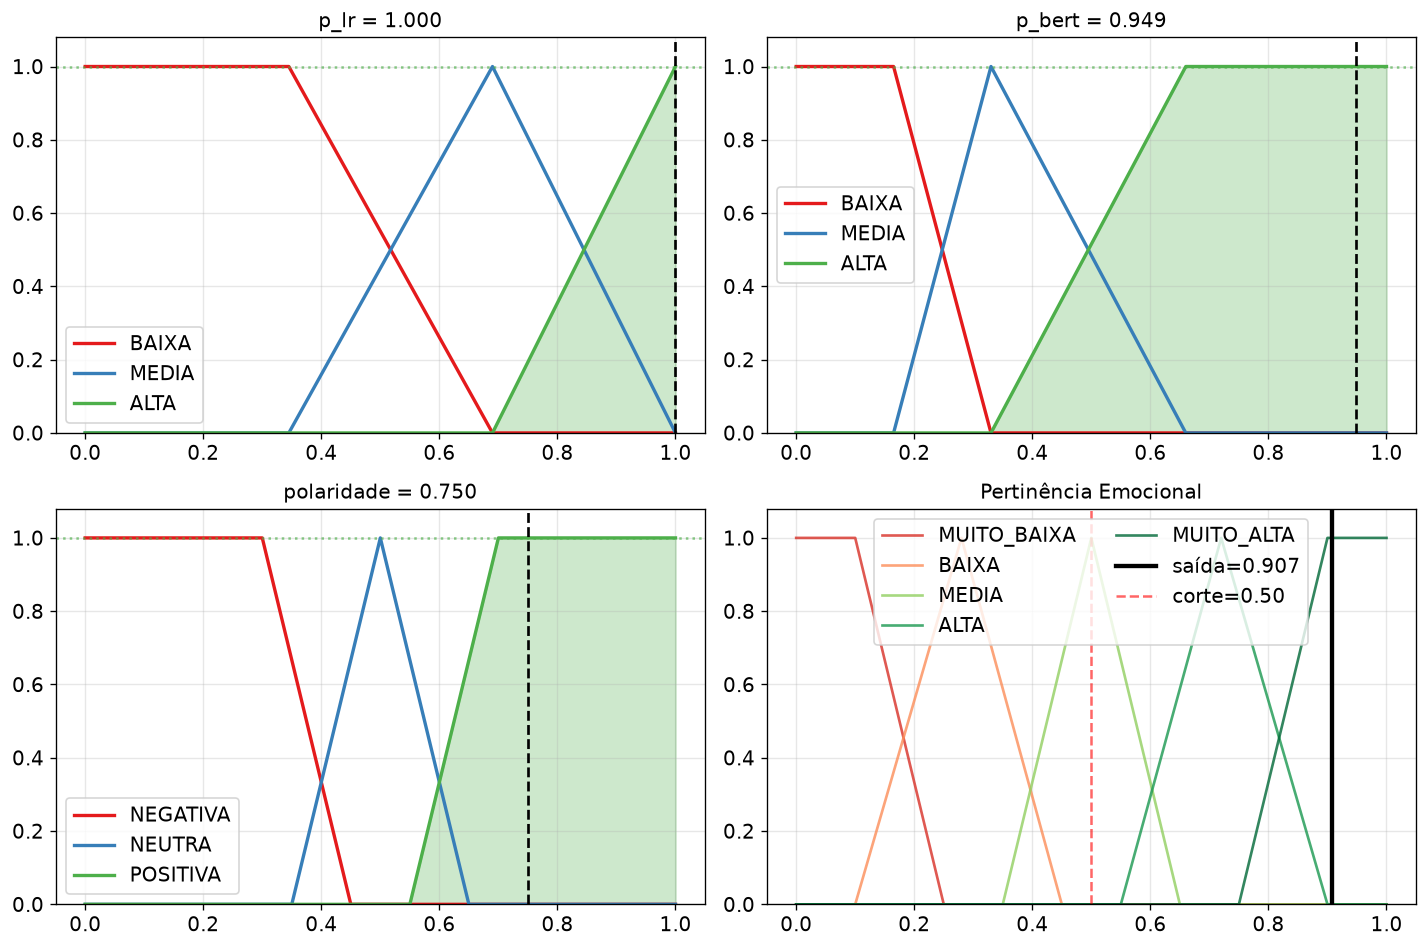


── AUDITORIA: regras disparadas ──


,disparo,origem,regra
0,1.0,dados,SE p_lr é ALTA E p_bert é ALTA E polaridade é POSITIVA ENTÃO pertinência é MUITO_ALTA


In [21]:
def visualizar_ativacao(emo, df_reg, p_lr_v, p_bert_v, pol_v, titulo=""):
    sim, (v_lr, v_bert, v_pol, v_pert) = criar_fis(emo, df_reg, 'centroid')
    saida = inferir(emo, df_reg, p_lr_v, p_bert_v, pol_v)

    # Paleta sem amarelo apagado
    PALETA_VARIAVEIS = [
        "#E41A1C",  # vermelho
        "#377EB8",  # azul
        "#4DAF4A",  # verde
        "#984EA3",  # roxo
        "#FF7F00",  # laranja
    ]

    PALETA_PERT = [
        "#D73027",
        "#FC8D59",
        "#91CF60",
        "#1A9850",
        "#006837", 
    ]

    # 2 gráficos em cima e 2 embaixo
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for ax, var, universo, termos, val, nome in [
        (axes[0], v_lr,   U_P,   TERMOS_P,   p_lr_v,   'p_lr'),
        (axes[1], v_bert, U_P,   TERMOS_P,   p_bert_v, 'p_bert'),
        (axes[2], v_pol,  U_POL, TERMOS_POL, pol_v,    'polaridade'),
    ]:

        cores = PALETA_VARIAVEIS[:len(termos)]

        for t, c in zip(termos, cores):

            ax.plot(
                universo,
                var[t].mf,
                color=c,
                linewidth=2,
                label=t
            )

            g = float(np.interp(val, universo, var[t].mf))

            if g > 0.01:
                ax.fill_between(
                    universo,
                    0,
                    np.minimum(var[t].mf, g),
                    color=c,
                    alpha=0.28
                )

                ax.axhline(
                    g,
                    color=c,
                    linestyle=':',
                    alpha=0.65
                )

        ax.axvline(
            val,
            color='black',
            linestyle='--',
            linewidth=1.6
        )

        ax.set_title(
            f'{nome} = {val:.3f}',
            fontsize=12
        )

        ax.set_ylim(0, 1.08)

        ax.legend(fontsize=12)

        ax.grid(True, alpha=0.3)

        ax.tick_params(
            axis='both',
            labelsize=12
        )

    # =====================================================
    # Saída fuzzy
    # =====================================================

    ax = axes[3]

    cores = PALETA_PERT[:len(TERMOS_PERT)]

    for t, c in zip(TERMOS_PERT, cores):

        ax.plot(
            U_PERT,
            v_pert[t].mf,
            color=c,
            linewidth=1.6,
            label=t,
            alpha=0.8
        )

    ax.axvline(
        saida,
        color='black',
        linewidth=2.6,
        label=f'saída={saida:.3f}'
    )

    ax.axvline(
        0.5,
        color='red',
        linestyle='--',
        alpha=0.6,
        label='corte=0.50'
    )

    ax.set_title(
        'Pertinência Emocional',
        fontsize=12
    )

    ax.set_ylim(0, 1.08)

    ax.legend(
        fontsize=12,
        ncol=2
    )

    ax.grid(True, alpha=0.3)

    ax.tick_params(
        axis='both',
        labelsize=12
    )

    plt.tight_layout()
    plt.show()

    return saida


def regras_disparadas(emo, df_reg, p_lr_v, p_bert_v, pol_v, top=5):
    """AUDITORIA: quais regras dispararam e com que força."""
    v_lr   = build_prob_antecedent('p_lr',   tau_lr[emo])
    v_bert = build_prob_antecedent('p_bert', tau_bert[emo])
    v_pol  = build_polaridade()

    linhas = []

    for _, r in df_reg.iterrows():
        g = (
            float(np.interp(p_lr_v, U_P, v_lr[r['t_lr']].mf)) *
            float(np.interp(p_bert_v, U_P, v_bert[r['t_bert']].mf)) *
            float(np.interp(pol_v, U_POL, v_pol[r['t_pol']].mf))
        )

        if g > 1e-4:
            linhas.append({
                'disparo': round(g, 4),
                'origem': r['origem'],
                'regra': (
                    f"SE p_lr é {r['t_lr']} E p_bert é {r['t_bert']} "
                    f"E polaridade é {r['t_pol']} "
                    f"ENTÃO pertinência é {r['t_pert']}"
                )
            })

    return (
        pd.DataFrame(linhas)
        .sort_values('disparo', ascending=False)
        .head(top)
    )


# Demonstração num caso real do fold de teste
j = EMOTION_COLS.index(EMO_BEST)

pos = np.where(
    Y_folds[FOLD_DEMO][:, j] == 1
)[0]

i = int(pos[0])

print(
    f'TEXTO REAL: "{TEXT_folds[FOLD_DEMO][i][:180]}"'
)

print(
    f'Rótulo verdadeiro para {EMO_BEST}: '
    f'{Y_folds[FOLD_DEMO][i, j]}\n'
)


visualizar_ativacao(
    EMO_BEST,
    df_wm_best,
    P_LR_folds[FOLD_DEMO][i, j],
    P_BERT_folds[FOLD_DEMO][i, j],
    POL_folds[FOLD_DEMO][i],
    "— exemplo real (positivo)"
)


print("\n── AUDITORIA: regras disparadas ──")


pd.set_option('display.max_colwidth', None)
display(
    regras_disparadas(
        EMO_BEST,
        df_wm_best,
        P_LR_folds[FOLD_DEMO][i, j],
        P_BERT_folds[FOLD_DEMO][i, j],
        POL_folds[FOLD_DEMO][i]
    )
)

## Superfície de resposta e defuzzificação

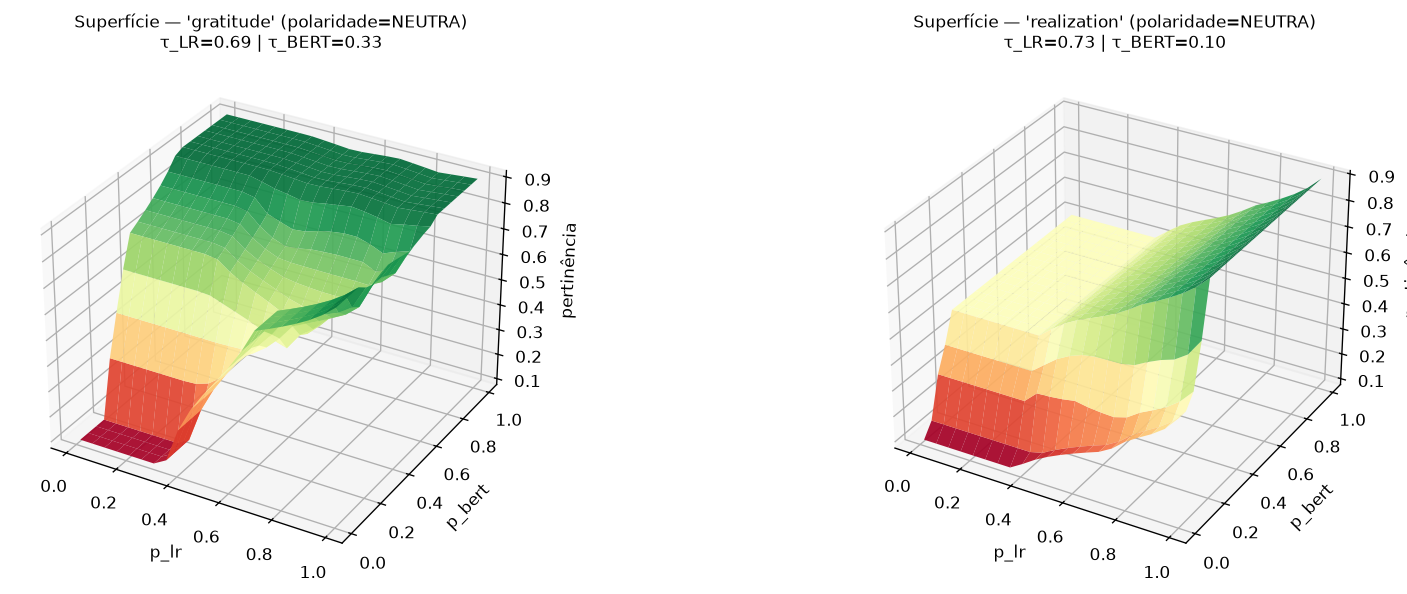

Leitura: o patamar da superfície muda de posição conforme τ — o sistema
'aprendeu' que cada emoção tem um ponto de decisão diferente.

===== DEFUZZIFICAÇÃO — emoção 'gratitude' =====


Defuzz,Bissecção,Centroide,Maior Máximo,Menor Máximo,Média Máximos
Cenário,,,,,
"Ambos altos, pol. negativa",0.760,0.773,0.783,0.660,0.721
"Ambos altos, pol. neutra",0.899,0.897,1.000,0.847,0.923
"Ambos altos, pol. positiva",0.899,0.897,1.000,0.847,0.923
Ambos discordam (baixo),0.087,0.093,0.100,0.000,0.050
"LR alto, BERT baixo",0.760,0.773,0.783,0.660,0.721
"LR baixo, BERT alto",0.912,0.907,1.000,0.900,0.950
Zona de dúvida (≈τ),0.500,0.500,0.500,0.500,0.500


In [22]:
# ── Superfície de resposta: p_lr × p_bert → pertinência ──────────
def superficie(emo, df_reg, pol_fix=0.5, n=21):
    gx = np.linspace(0.01, 0.99, n)
    Z = np.zeros((n, n))
    for a, plr in enumerate(gx):
        for b, pbe in enumerate(gx):
            Z[a, b] = inferir(emo, df_reg, plr, pbe, pol_fix)
    return gx, Z

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
fig = plt.figure(figsize=(16, 5))
for idx, (emo, df_reg) in enumerate([(EMO_BEST, df_wm_best), (EMO_WORST, df_wm_worst)], 1):
    gx, Z = superficie(emo, df_reg)
    X, Y = np.meshgrid(gx, gx, indexing='ij')
    ax = fig.add_subplot(1, 2, idx, projection='3d')
    ax.plot_surface(X, Y, Z, cmap='RdYlGn', edgecolor='none', alpha=0.92)
    ax.set_xlabel('p_lr'); ax.set_ylabel('p_bert'); ax.set_zlabel('pertinência')
    ax.set_title(f"Superfície — '{emo}' (polaridade=NEUTRA)\n"
                 f"τ_LR={tau_lr[emo]:.2f} | τ_BERT={tau_bert[emo]:.2f}", fontsize=10)
plt.tight_layout()
plt.savefig(OUT_INTERP / "superficies.png", dpi=180, bbox_inches='tight')
plt.show()
print("Leitura: o patamar da superfície muda de posição conforme τ — o sistema\n"
      "'aprendeu' que cada emoção tem um ponto de decisão diferente.")

# ── Comparação de métodos de defuzzificação ─────────────────────
METODOS_DEFUZZ = ['centroid', 'bisector', 'mom', 'som', 'lom']
NOMES_DEFUZZ = {'centroid': 'Centroide', 'bisector': 'Bissecção',
                'mom': 'Média Máximos', 'som': 'Menor Máximo', 'lom': 'Maior Máximo'}

pontos = [
    ("Ambos discordam (baixo)",    0.05, 0.02, 0.50),
    ("LR alto, BERT baixo",        0.80, 0.05, 0.50),
    ("LR baixo, BERT alto",        0.05, 0.80, 0.50),
    ("Ambos altos, pol. neutra",   0.80, 0.80, 0.50),
    ("Ambos altos, pol. positiva", 0.80, 0.80, 0.90),
    ("Ambos altos, pol. negativa", 0.80, 0.80, 0.10),
    ("Zona de dúvida (≈τ)",        float(tau_lr[EMO_BEST]), float(tau_bert[EMO_BEST]), 0.50),
]
linhas = []
for nome, plr, pbe, pl in pontos:
    for dz in METODOS_DEFUZZ:
        try:
            v = inferir(EMO_BEST, df_wm_best, plr, pbe, pl, defuzz=dz)
        except Exception:
            v = np.nan
        linhas.append({"Cenário": nome, "Defuzz": NOMES_DEFUZZ[dz], "Pertinência": round(v, 3)})
df_dz = pd.DataFrame(linhas)
print(f"\n===== DEFUZZIFICAÇÃO — emoção '{EMO_BEST}' =====")
display(df_dz.pivot(index="Cenário", columns="Defuzz", values="Pertinência"))

## Cenários: mensagens de pacientes

In [23]:
# ══════════════════════════════════════════════════════════════════
# CENÁRIOS DE APLICAÇÃO — consultor monitorando mensagens de pacientes
#
# Nota metodológica: usamos mensagens REAIS do conjunto de teste (fold 1),
# selecionadas por palavras-chave do domínio. Assim aproveitamos as
# probabilidades OOF já calculadas — nenhum modelo é reexecutado, e nenhuma
# mensagem foi vista no treino do fold.
# ══════════════════════════════════════════════════════════════════
def perfil_emocional(fold, i, df_reg_por_emo=None, corte=0.5, top=6):
    """Roda os 28 FIS para uma mensagem e devolve o perfil de pertinência."""
    graus = {}
    for emo in EMOTION_COLS:
        df_reg = (df_reg_por_emo or {}).get(emo)
        if df_reg is None:
            df_reg = wang_mendel(emo, fold_demo=fold)
            (df_reg_por_emo or {})[emo] = df_reg
        j = EMOTION_COLS.index(emo)
        graus[emo] = inferir(emo, df_reg,
                             P_LR_folds[fold][i, j], P_BERT_folds[fold][i, j],
                             POL_folds[fold][i])
    s = pd.Series(graus).sort_values(ascending=False)
    return s.head(top), s[s >= corte].index.tolist()

# Busca mensagens com cara de paciente no fold de teste
PALAVRAS = ['sozinh', 'ansios', 'não aguento', 'nao aguento', 'cansad', 'medo',
            'triste', 'obrigad', 'ajuda', 'melhor', 'esperança', 'esperanca']
textos = TEXT_folds[FOLD_DEMO]
cands = [i for i, t in enumerate(textos)
         if any(p in t.lower() for p in PALAVRAS) and 25 < len(t) < 160]
print(f"Mensagens candidatas encontradas: {len(cands)}")

CACHE_REGRAS = {EMO_BEST: df_wm_best, EMO_WORST: df_wm_worst}
N_CENARIOS = 4   # aumente se quiser mais (cada um roda 28 FIS)

for c, i in enumerate(cands[:N_CENARIOS], 1):
    print("\n" + "═" * 66)
    print(f"CENÁRIO {c}")
    print("═" * 66)
    print(f'Mensagem: "{textos[i]}"')
    reais = [e for e in EMOTION_COLS if Y_folds[FOLD_DEMO][i, EMOTION_COLS.index(e)] == 1]
    print(f'Emoções anotadas (verdade): {reais}')
    print(f'Polaridade léxica: {POL_folds[FOLD_DEMO][i]:.2f}')

    perfil, sinalizadas = perfil_emocional(FOLD_DEMO, i, CACHE_REGRAS)
    print(f'\nPerfil de pertinência (top 6):')
    for emo, g in perfil.items():
        barra = '█' * int(g * 30)
        marca = '←' if emo in reais else ' '
        print(f'  {emo:15s} {g:.3f} |{barra:<30}| {marca}')
    print(f'\nEmoções sinalizadas ao consultor (pertinência ≥ 0.50): {sinalizadas}')

Mensagens candidatas encontradas: 984

══════════════════════════════════════════════════════════════════
CENÁRIO 1
══════════════════════════════════════════════════════════════════
Mensagem: "fico feliz ouvi-lo voce merece sua melhor vida sem esse abuso negatividade"
Emoções anotadas (verdade): ['caring', 'joy']
Polaridade léxica: 0.83

Perfil de pertinência (top 6):
  joy             0.895 |██████████████████████████    | ←
  admiration      0.565 |████████████████              |  
  caring          0.533 |███████████████               | ←
  realization     0.105 |███                           |  
  annoyance       0.093 |██                            |  
  approval        0.093 |██                            |  

Emoções sinalizadas ao consultor (pertinência ≥ 0.50): ['joy', 'admiration', 'caring']

══════════════════════════════════════════════════════════════════
CENÁRIO 2
══════════════════════════════════════════════════════════════════
Mensagem: "sim saude esperando que seja m

## Auditoria completa de um caso

In [24]:
i = cands[0]
EMO_AUDIT = EMO_BEST
j = EMOTION_COLS.index(EMO_AUDIT)

print("═" * 66)
print(f"AUDITORIA COMPLETA — emoção '{EMO_AUDIT}'")
print("═" * 66)
print(f'\n[1] MENSAGEM\n    "{textos[i]}"')
print(f'\n[2] ENTRADAS CRISP')
print(f'    p_lr       = {P_LR_folds[FOLD_DEMO][i, j]:.4f}  (τ_LR   = {tau_lr[EMO_AUDIT]:.2f})')
print(f'    p_bert     = {P_BERT_folds[FOLD_DEMO][i, j]:.4f}  (τ_BERT = {tau_bert[EMO_AUDIT]:.2f})')
print(f'    polaridade = {POL_folds[FOLD_DEMO][i]:.4f}')

v_lr   = build_prob_antecedent('p_lr',   tau_lr[EMO_AUDIT])
v_bert = build_prob_antecedent('p_bert', tau_bert[EMO_AUDIT])
v_pol  = build_polaridade()
print(f'\n[3] FUZZIFICAÇÃO')
for nome, var, universo, termos, val in [
    ('p_lr',       v_lr,   U_P,   TERMOS_P,   P_LR_folds[FOLD_DEMO][i, j]),
    ('p_bert',     v_bert, U_P,   TERMOS_P,   P_BERT_folds[FOLD_DEMO][i, j]),
    ('polaridade', v_pol,  U_POL, TERMOS_POL, POL_folds[FOLD_DEMO][i]),
]:
    graus = {t: round(float(np.interp(val, universo, var[t].mf)), 3) for t in termos}
    print(f'    {nome:11s}: {graus}')

print(f'\n[4] REGRAS DISPARADAS')
display(regras_disparadas(EMO_AUDIT, df_wm_best, P_LR_folds[FOLD_DEMO][i, j],
                          P_BERT_folds[FOLD_DEMO][i, j], POL_folds[FOLD_DEMO][i], top=5))

g = inferir(EMO_AUDIT, df_wm_best, P_LR_folds[FOLD_DEMO][i, j],
            P_BERT_folds[FOLD_DEMO][i, j], POL_folds[FOLD_DEMO][i])
print(f'\n[5] DEFUZZIFICAÇÃO (centroide)\n    pertinência = {g:.4f}')
print(f'\n[6] DECISÃO\n    {"SINALIZAR" if g >= 0.5 else "não sinalizar"} '
      f'(corte=0.50) | verdade = {Y_folds[FOLD_DEMO][i, j]}')
print(f'\n[7] EXPLICAÇÃO AO CONSULTOR')
print(f'    "A mensagem foi sinalizada como {EMO_AUDIT} porque o BERTimbau atribuiu\n'
      f'     evidência {"ALTA" if P_BERT_folds[FOLD_DEMO][i,j] > tau_bert[EMO_AUDIT] else "BAIXA"} '
      f'(acima/abaixo do ponto de decisão {tau_bert[EMO_AUDIT]:.2f}),\n'
      f'     o léxico indicou polaridade {POL_folds[FOLD_DEMO][i]:.2f}, e a regra de maior\n'
      f'     disparo na base concluiu pertinência {g:.2f}."')

══════════════════════════════════════════════════════════════════
AUDITORIA COMPLETA — emoção 'gratitude'
══════════════════════════════════════════════════════════════════

[1] MENSAGEM
    "fico feliz ouvi-lo voce merece sua melhor vida sem esse abuso negatividade"

[2] ENTRADAS CRISP
    p_lr       = 0.0801  (τ_LR   = 0.69)
    p_bert     = 0.1635  (τ_BERT = 0.33)
    polaridade = 0.8333

[3] FUZZIFICAÇÃO
    p_lr       : {'BAIXA': 1.0, 'MEDIA': 0.0, 'ALTA': 0.0}
    p_bert     : {'BAIXA': 1.0, 'MEDIA': 0.0, 'ALTA': 0.0}
    polaridade : {'NEGATIVA': 0.0, 'NEUTRA': 0.0, 'POSITIVA': 1.0}

[4] REGRAS DISPARADAS


,disparo,origem,regra
0,1.0,dados,SE p_lr é BAIXA E p_bert é BAIXA E polaridade é POSITIVA ENTÃO pertinência é MUITO_BAIXA



[5] DEFUZZIFICAÇÃO (centroide)
    pertinência = 0.0929

[6] DECISÃO
    não sinalizar (corte=0.50) | verdade = 0

[7] EXPLICAÇÃO AO CONSULTOR
    "A mensagem foi sinalizada como gratitude porque o BERTimbau atribuiu
     evidência BAIXA (acima/abaixo do ponto de decisão 0.33),
     o léxico indicou polaridade 0.83, e a regra de maior
     disparo na base concluiu pertinência 0.09."


## Exportação e conclusões

In [25]:
df_wm_best.to_csv(OUT_INTERP / f"maf_dados_{EMO_BEST}.csv", index=False)
df_wm_worst.to_csv(OUT_INTERP / f"maf_dados_{EMO_WORST}.csv", index=False)
gerar_maf_especialista(EMO_BEST).to_csv(OUT_INTERP / f"maf_especialista_{EMO_BEST}.csv", index=False)
pd.DataFrame({"tau_bert": tau_bert, "tau_lr": tau_lr,
              "base_rate": base_rates.reindex(EMOTION_COLS),
              "f1_bert_tuned": f1_lab.reindex(EMOTION_COLS),
              "valencia": pd.Series(VALENCIA).reindex(EMOTION_COLS)}
             ).to_csv(OUT_INTERP / "variaveis_por_emocao.csv")
print("Exportado para", OUT_INTERP.resolve())

Exportado para C:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\data\out\ensemble_fuzzy_interpretacao


# Conclusões

**Projeto do SIN.** Mamdani tipo-1, 3 antecedentes × 3 termos = 27 regras por emoção,
saída com 5 termos. Legível por um humano — a MAF inteira cabe em três tabelas 3×3.

**A decisão de projeto central.** Os termos de `p_lr`/`p_bert` são ancorados no ponto de
decisão τ calibrado por emoção, não em quantis dos dados. Consequências:
1. `ALTA` significa literalmente "acima do ponto de decisão" — o rótulo não mente.
2. Extremos são trapézios (ombros monótonos): μ satura e permanece. Gaussianas nos extremos
   seriam não-monótonas, penalizando as predições mais confiantes.
3. Cada emoção ganha sua própria escala linguística — τ varia de ~0.10 a ~0.50.

**Achado interpretável.** τ_LR ≈ 0.66 contra τ_BERT ≈ 0.28: os dois modelos operam em escalas
de evidência opostas. O SMOTE reequilibra o treino do LR e infla suas probabilidades; a
CB-Loss do BERTimbau preserva a distribuição real. Um limiar único de 0.5 é inadequado para
ambos — e para 28/28 emoções.

**Especialista × dados.** A MAF do especialista codifica heurísticas de domínio (BERT com peso
dobrado; polaridade reforça ou atenua conforme a valência da emoção). A MAF de Wang–Mendel
extrai as mesmas células dos dados OOF. A comparação mostra onde o conhecimento de domínio e a
evidência empírica concordam — e onde divergem. Células sem suporte de dados são preenchidas
pelo especialista, garantindo cobertura total do espaço de entrada.

**Auditabilidade.** Para qualquer mensagem, o sistema expõe a cadeia inteira: entradas crisp →
graus de pertinência em cada termo → regras disparadas com sua força → agregação →
defuzzificação → decisão. O consultor recebe uma justificativa em linguagem natural, não um
escore opaco.

**Limitações — declaradas honestamente.**
- *Custo de desempenho.* Discretizar duas probabilidades contínuas em 9 células perde
  resolução. O ensemble fica ~0.05 de F1-macro abaixo do BERTimbau com limiar calibrado. Este
  trabalho troca desempenho por explicabilidade — deliberadamente, e com o custo medido.
- *Polaridade fraca.* O léxico devolve 0.5 (neutro) para a maioria dos textos, então a terceira
  entrada contribui pouco. Um analisador de sentimento neural daria mais sinal.
- *Emoções raras.* Para labels com base rate < 0.5% (ex.: `grief`), poucas células têm suporte
  e a base depende do especialista — o sistema fica honesto sobre o que não sabe, o que é
  preferível a inventar regras.
- *τ vem dos dados.* A âncora semântica é calibrada out-of-fold, não escolhida por um
  especialista. É uma escolha de projeto defensável, mas mistura dados e conhecimento.